*NLP @ HSE DSBA, autumn 2026. Author: Daria Andreeva*

# Seminar 3 — Attention and the Transformer

So, do you remember where we stoped last week? A bidirectional LSTM read a German sentence, squeezed everything it knew into 256 numbers, and a second LSTM wrote the English from that one vector. It worked — BLEU 13 on Multi30k — and it worked worse the longer the sentence was: 18 BLEU on short captions, 8.5 on long ones. We called that the bottleneck, we showed that a wider vector lifts the whole curve without flattening it, and we promised the fix would be this week's topic.

Here it is. The fix is embarrassingly simple to state: let's stop trying to put all the info into one cell, but instead let the decoder see everything before it. The mechanism that does the looking is called attention, and it turned out to be something more than a patch for translation. So we'll take it and use different architectures with the same concept.


### The claim for today:

$$\text{context}_t \;=\; \sum_{i} \underbrace{\mathrm{softmax}_i\big(\mathrm{score}(q_t, k_i)\big)}_{\text{weights}}\; v_i$$

**Attention is a differentiable lookup: a query, a set of keys, a weighted sum of values.** One formula, three degrees of freedom (three matrices, see) — *how* the score is computed, *what* plays query and key, and *which set* the keys come from — and everything sits somewhere on those three axes. We'' approach it step by step.

Three claims we will test against numbers today:

1. **The bottleneck is cured by access, not by width.** -- we've already stated it, so the only thing left is to check it.
2. **The score function barely matters; the scale does.** Additive and dot-product attention land within noise of each other.
3. **Self-attention is a set operation.** Without positional information the encoder cannot tell "dog bites man" from "man bites dog" — and we measure what that costs.

# Some dependencies

In [ ]:
# Colab setup. If needed, uncomment the following lines to install dependencies and clone the repository.
# The notebook reads Multi30k and the tokenizers from ../week02_language_modelling, so clone the whole repo.
#!pip install -q torch tokenizers sacrebleu
#!git clone -q --branch autumn-2026 https://github.com/xufana/dsba_nlp.git
#%cd dsba_nlp/week03_attention_transformer

In [25]:
import json
import math
import os
import random
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from tokenizers import Tokenizer
import sacrebleu

warnings.filterwarnings("ignore")

SEED = 42


def seed_all(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


seed_all()
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

# Week 2 owns the data and the tokenizers; this week owns the models trained on top of them.
W2 = "../week02_language_modelling"
DATA_DIR = f"{W2}/data"          # Multi30k
W2_ART = f"{W2}/artifacts"       # bpe_de_8k.json, bpe_en_8k.json, seq2seq_lstm.pt
ART_DIR = "artifacts"            # this week's weights and curves
RECOMPUTE = False                # True: rebuild every artifact with precompute.py (hours on a laptop)

PAD, UNK, BOS, EOS = 0, 1, 2, 3
SPECIALS = ["[PAD]", "[UNK]", "[BOS]", "[EOS]"]


def log(msg):
    print(msg, flush=True)


def n_params(*modules):
    """Parameter count of one module, or of several taken together."""
    return sum(p.numel() for m in modules for p in m.parameters())


def show_params(label, module, **parts):
    """One line: `module`'s parameters, split into the named parts. What is left over is "other"."""
    total = n_params(module)
    counts = {name: n_params(*part) if isinstance(part, (list, tuple)) else n_params(part)
              for name, part in parts.items()}
    counts["other"] = total - sum(counts.values())
    split = "   ".join(f"{name} {k:,} ({k / total:.0%})" for name, k in counts.items() if k)
    print(f"{label}: {total:,} parameters   |   {split}")


def check(label, ok):
    print(("✓ " if ok else "✗ ") + label)

device: mps


# 0. Where we stopped

## 0.1 The data, again

Quick recap:

Multi30k: 29 000 image captions in German with their English translations, 1 000 for validation, 1 000 for test. The tokenizers are the two 8k BPE models from the last week.

In [2]:
def load_multi30k(data_dir, split):
    with open(os.path.join(data_dir, f"{split}.de"), encoding="utf-8") as f:
        de = [l.strip() for l in f]
    with open(os.path.join(data_dir, f"{split}.en"), encoding="utf-8") as f:
        en = [l.strip() for l in f]
    assert len(de) == len(en)
    return de, en


def s2s_encode(tok_src, tok_trg, src_texts, trg_texts, max_len=50):
    src = [torch.tensor(e.ids[:max_len], dtype=torch.long) for e in tok_src.encode_batch(src_texts)]
    trg = [torch.tensor([BOS] + e.ids[:max_len] + [EOS], dtype=torch.long) for e in tok_trg.encode_batch(trg_texts)]
    return src, trg


def s2s_batches(src, trg, batch_size, shuffle, device):
    order = np.random.permutation(len(src)) if shuffle else np.arange(len(src))
    for i in range(0, len(src), batch_size):
        idx = order[i:i + batch_size]
        s = pad_sequence([src[j] for j in idx], batch_first=True, padding_value=PAD)
        t = pad_sequence([trg[j] for j in idx], batch_first=True, padding_value=PAD)
        s_len = torch.tensor([len(src[j]) for j in idx])
        yield s.to(device), s_len.to(device), t.to(device)


def ids_to_text(tok, ids):
    out = []
    for row in ids.tolist():
        cut = row.index(EOS) if EOS in row else len(row)
        out.append(tok.decode([i for i in row[:cut] if i not in (PAD, BOS, EOS)]))
    return out

In [3]:
tok_de = Tokenizer.from_file(f"{W2_ART}/bpe_de_8k.json")
tok_en = Tokenizer.from_file(f"{W2_ART}/bpe_en_8k.json")
V_DE, V_EN = tok_de.get_vocab_size(), tok_en.get_vocab_size()

tr_de, tr_en = load_multi30k(DATA_DIR, "train")
va_de, va_en = load_multi30k(DATA_DIR, "val")
te_de, te_en = load_multi30k(DATA_DIR, "test")
tr_src, tr_trg = s2s_encode(tok_de, tok_en, tr_de, tr_en)
va_src, va_trg = s2s_encode(tok_de, tok_en, va_de, va_en)
te_src, te_trg = s2s_encode(tok_de, tok_en, te_de, te_en)
data = ((tr_src, tr_trg), (va_src, va_trg, va_en))     # the tuple every training function below takes

print(f"train {len(tr_src):,}   val {len(va_src):,}   test {len(te_src):,}   vocab de {V_DE:,} / en {V_EN:,}")
print(te_de[0]); print(tok_de.encode(te_de[0]).tokens)
print(te_en[0]); print(tok_en.encode(te_en[0]).tokens)

train 29,000   val 1,014   test 1,000   vocab de 8,000 / en 8,000
Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.
['▁Ein', '▁Mann', '▁mit', '▁einem', '▁orangefarbenen', '▁Hut', ',', '▁der', '▁etwas', '▁an', 'st', 'arr', 't', '.']
A man in an orange hat starring at something.
['▁A', '▁man', '▁in', '▁an', '▁orange', '▁hat', '▁starring', '▁at', '▁something', '.']


## 0.2 The results table

We'll fill it during the seminar: compare all the configurations and see different types of attention and, basically, its evolution.

In [4]:
results = []


def record(model, params, test_bleu, by_len, s_per_epoch=None, note=""):
    results.append({
        "model": model,
        "params": f"{params / 1e6:.1f}M" if isinstance(params, (int, float)) else params,
        "test BLEU": round(test_bleu, 1),
        "BLEU 0-10": by_len.get("0-10"),      # source sentences of fewer than 10 BPE tokens
        "BLEU 25+": by_len.get("25-100"),      # 25 tokens and longer
        "s/epoch": None if s_per_epoch is None else round(s_per_epoch),
        "note": note,
    })


def show_results():
    return pd.DataFrame(results).set_index("model")


def epoch_seconds(sec):
    # week 2 stored seconds per epoch; this week's precompute stores cumulative seconds — normalise both
    cumulative = len(sec) > 1 and all(b > a for a, b in zip(sec, sec[1:])) and sec[-1] > 1.5 * sec[0]
    return sec[-1] / len(sec) if cumulative else float(np.mean(sec))

In [5]:
@torch.no_grad()
def s2s_bleu(model, tok_trg, src, trg, refs, device, batch_size=128):
    import sacrebleu
    model.eval()
    hyps = []
    for s, s_len, _ in s2s_batches(src, trg, batch_size, shuffle=False, device=device):
        out = model.greedy(s, s_len)
        ids = out[0] if isinstance(out, tuple) else out
        hyps.extend(ids_to_text(tok_trg, ids))
    return sacrebleu.corpus_bleu(hyps, [refs]).score, hyps


def bleu_by_src_len(hyps, refs, src):
    """BLEU per source-length bucket (in BPE tokens) — the bottleneck plot from week 2."""
    import sacrebleu
    lens = [len(s) for s in src]
    out = {}
    for lo, hi in [(0, 10), (10, 15), (15, 20), (20, 25), (25, 100)]:
        idx = [i for i, l in enumerate(lens) if lo <= l < hi]
        if len(idx) >= 20:
            out[f"{lo}-{hi}"] = round(sacrebleu.corpus_bleu([hyps[i] for i in idx], [[refs[i] for i in idx]]).score, 2)
    return out


def load_weights(model, path, device="cpu"):
    sd = torch.load(path, map_location=device)
    model.load_state_dict({k: (v.float() if v.is_floating_point() else v) for k, v in sd.items()})
    return model.to(device).eval()

## 0.3 baseline: last week model

The bidirectional LSTM encoder, a projection of its two final states down to one $(h_0, c_0)$, and an LSTM decoder that starts from there.

The weights are pre-computed, cuz I don't know what to talk about while it's training (abt 30 mins, btw).

In [6]:
class Seq2SeqLSTM(nn.Module):
    """Bidirectional LSTM encoder -> one vector -> LSTM decoder. No attention: the whole
    source sentence has to squeeze through (h0, c0)."""

    def __init__(self, src_vocab, trg_vocab, emb=256, hidden=256, dropout=0.2):
        super().__init__()
        self.hidden = hidden
        self.src_emb = nn.Embedding(src_vocab, emb, padding_idx=PAD)
        self.trg_emb = nn.Embedding(trg_vocab, emb, padding_idx=PAD)
        self.encoder = nn.LSTM(emb, hidden, batch_first=True, bidirectional=True)
        self.decoder = nn.LSTM(emb, hidden, batch_first=True)
        self.h_proj = nn.Linear(2 * hidden, hidden)
        self.c_proj = nn.Linear(2 * hidden, hidden)
        self.drop = nn.Dropout(dropout)
        self.out = nn.Linear(hidden, trg_vocab)

    def encode(self, src, src_len):
        e = self.drop(self.src_emb(src))
        packed = pack_padded_sequence(e, src_len.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, c) = self.encoder(packed)                      # h, c: (2, B, H) — forward and backward
        h = torch.tanh(self.h_proj(torch.cat([h[0], h[1]], dim=-1)))  # (B, H)  <- the bottleneck
        c = torch.tanh(self.c_proj(torch.cat([c[0], c[1]], dim=-1)))
        return h.unsqueeze(0), c.unsqueeze(0)

    def decode_step(self, y_prev, state):
        e = self.drop(self.trg_emb(y_prev))                   # (B, 1, E)
        o, state = self.decoder(e, state)
        return self.out(self.drop(o)), state                  # (B, 1, V)

    def forward(self, src, src_len, trg_in):
        # teacher forcing: the decoder reads the gold prefix, whatever it predicted
        state = self.encode(src, src_len)
        e = self.drop(self.trg_emb(trg_in))
        o, _ = self.decoder(e, state)
        return self.out(self.drop(o))                         # (B, T, V)

    @torch.no_grad()
    def greedy(self, src, src_len, max_len=40):
        state = self.encode(src, src_len)
        y = torch.full((src.size(0), 1), BOS, dtype=torch.long, device=src.device)
        out, done = [], torch.zeros(src.size(0), dtype=torch.bool, device=src.device)
        for _ in range(max_len):
            logits, state = self.decode_step(y, state)
            y = logits[:, -1].argmax(-1, keepdim=True)
            y = y.masked_fill(done.unsqueeze(1), PAD)
            out.append(y)
            done |= y.squeeze(1) == EOS
            if done.all():
                break
        return torch.cat(out, dim=1)

In [7]:
lstm0 = load_weights(Seq2SeqLSTM(V_DE, V_EN, emb=256, hidden=256), f"{W2_ART}/seq2seq_lstm.pt", device)
w2_curves = json.load(open(f"{W2_ART}/seq2seq_curves.json"))

t = time.time()
bleu0, hyps0 = s2s_bleu(lstm0, tok_en, te_src, te_trg, te_en, device)
bylen0 = bleu_by_src_len(hyps0, te_en, te_src)
print(f"test BLEU {bleu0:.2f}  by source length {bylen0}   ({time.time() - t:.0f}s to translate the test set)")
record("LSTM, no attention (week 2)", w2_curves["n_params"], bleu0, bylen0,
       s_per_epoch=epoch_seconds(w2_curves["seconds"]), note="one vector between the halves")

test BLEU 13.38  by source length {'0-10': 18.17, '10-15': 15.1, '15-20': 11.4, '20-25': 9.61, '25-100': 8.51}   (3s to translate the test set)


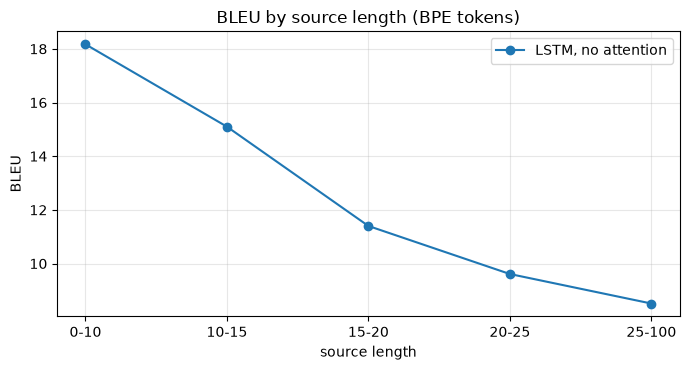

In [8]:
def plot_by_len(curves_by_name, title="BLEU by source length (BPE tokens)"):
    plt.figure(figsize=(7, 3.8))
    for name, by_len in curves_by_name.items():
        xs = list(range(len(by_len)))
        plt.plot(xs, list(by_len.values()), "o-", label=name)
        plt.xticks(xs, list(by_len.keys()))
    plt.xlabel("source length"); plt.ylabel("BLEU"); plt.title(title)
    plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()


plot_by_len({"LSTM, no attention": bylen0})

The experiment shows that the translation loses the details first — the nouns survive, the adjectives and the actions go.

The decoder currently gets 256 numbers for the whole sentence. Two ways to give it more: (a) make it 1 024 numbers; (b) keep the vector at 256 but let the decoder *re-read all the encoder states at every step*. Which one flattens the curve — and how many parameters does (b) add? Write down a number, and we check the real outcome.

In [9]:
SHOW = [i for i in range(len(te_src)) if 14 <= len(te_src[i]) <= 22][:3]     # three mid-length test sentences


def show_translations(hyps, idx=SHOW):
    for i in idx:
        print(f"DE   {te_de[i]}\nREF  {te_en[i]}\nHYP  {hyps[i]}\n")


show_translations(hyps0)

DE   Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.
REF  A man in an orange hat starring at something.
HYP  A man with a beard is looking at a camera.

DE   Ein Boston Terrier läuft über saftig-grünes Gras vor einem weißen Zaun.
REF  A Boston Terrier is running on lush green grass in front of a white fence.
HYP  A shaggy player is running with a white dog in the background on the ground.

DE   Fünf Leute in Winterjacken und mit Helmen stehen im Schnee mit Schneemobilen im Hintergrund.
REF  Five people wearing winter jackets and helmets stand in the snow, with snowmobiles in the background.
HYP  Five people in red and red uniforms are standing in the middle of a city street with the other people.



# 1. Attention in seq2seq

## 1.1 The recipe

Last week we threw all of the hidden states of encoder away except the last one. Attention (Bahdanau, Cho & Bengio 2015) keeps them and lets the decoder consult them. At every decoding step $t$:

1. **score** every encoder state against the current decoder state: $e_{t,i} = \mathrm{score}(s_t, h_i)$;
2. **normalise** the scores into weights with a softmax over the source positions: $\alpha_{t,i} = \mathrm{softmax}_i(e_{t,i})$;
3. **aggregate**: the context is the weighted sum of the encoder states, $c_t = \sum_i \alpha_{t,i}\, h_i$.

The context $c_t$ is a different vector at every step — from the point of how it is seen from the word being produced right now. The decoder gets it on top of its own state, and the output layer reads both. Three names that stick for the rest of the course: the decoder state is the **query**, the encoder states are the **keys** (what the score is computed against) and the **values** (what gets summed). Here keys and values are the same vectors yet.

One more detail: **input feeding** (Luong et al. 2015). The previous step's context $c_{t-1}$ is concatenated to the decoder's input at step $t$, so the decoder knows where it looked last time — without it, the model tends to translate the same source word twice or skip one.

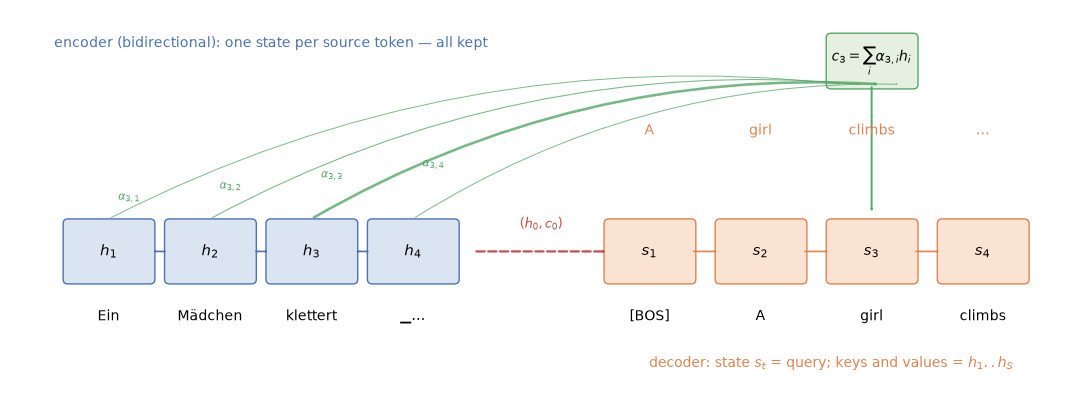

In [10]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def draw_attn_seq2seq():
    src = ["Ein", "Mädchen", "klettert", "▁…"]; trg = ["[BOS]", "A", "girl", "climbs"]
    fig, ax = plt.subplots(figsize=(11, 4.2)); ax.axis("off")
    ax.set_xlim(0, 11); ax.set_ylim(0, 4.2)
    hx = []
    for i, t in enumerate(src):
        x = 0.6 + i * 1.05
        ax.add_patch(FancyBboxPatch((x, 1.3), 0.85, 0.6, boxstyle="round,pad=0.05", fc="#dbe5f1", ec="#4c72b0"))
        ax.text(x + 0.42, 1.6, f"$h_{i + 1}$", ha="center", va="center", fontsize=11)
        ax.text(x + 0.42, 0.9, t, ha="center", va="center", fontsize=10)
        if i: ax.add_patch(FancyArrowPatch((x - 0.2, 1.6), (x, 1.6), arrowstyle="<->", color="#4c72b0", lw=1.2))
        hx.append(x + 0.42)
    for j, t in enumerate(trg):
        x = 6.2 + j * 1.15
        ax.add_patch(FancyBboxPatch((x, 1.3), 0.85, 0.6, boxstyle="round,pad=0.05", fc="#fbe3d4", ec="#dd8452"))
        ax.text(x + 0.42, 1.6, f"$s_{j + 1}$", ha="center", va="center", fontsize=11)
        ax.text(x + 0.42, 0.9, t, ha="center", va="center", fontsize=10)
        ax.text(x + 0.42, 2.9, trg[j + 1] if j + 1 < len(trg) else "…", ha="center", va="center", fontsize=10, color="#dd8452")
        if j: ax.add_patch(FancyArrowPatch((x - 0.3, 1.6), (x, 1.6), arrowstyle="->", color="#dd8452", lw=1.2))
    # the attention for one decoder step: every h_i -> c_3 -> s_3
    qx = 6.2 + 2 * 1.15 + 0.42
    ax.add_patch(FancyBboxPatch((qx - 0.42, 3.4), 0.85, 0.5, boxstyle="round,pad=0.05", fc="#e5f0e0", ec="#55a868"))
    ax.text(qx, 3.65, "$c_3=\\sum_i \\alpha_{3,i} h_i$", ha="center", va="center", fontsize=10)
    for i, x in enumerate(hx):
        ax.add_patch(FancyArrowPatch((x, 1.95), (qx - 0.3 + i * 0.2, 3.4), arrowstyle="->", color="#55a868",
                                     lw=0.6 + 1.6 * [0.05, 0.1, 0.8, 0.05][i], alpha=.8, connectionstyle="arc3,rad=-0.15"))
        ax.text(x + 0.1, 2.15 + 0.12 * i, f"$\\alpha_{{3,{i + 1}}}$", fontsize=8, color="#55a868")
    ax.add_patch(FancyArrowPatch((qx, 3.4), (qx, 2.0), arrowstyle="->", color="#55a868", lw=1.4))
    ax.text(2.7, 3.8, "encoder (bidirectional): one state per source token — all kept", ha="center", fontsize=10, color="#4c72b0")
    ax.text(8.5, 0.35, "decoder: state $s_t$ = query; keys and values = $h_1..h_S$", ha="center", fontsize=10, color="#dd8452")
    ax.add_patch(FancyArrowPatch((4.8, 1.6), (6.2, 1.6), arrowstyle="->", color="#c44e52", lw=1.6, ls="--"))
    ax.text(5.5, 1.85, "$(h_0, c_0)$", ha="center", fontsize=9, color="#c44e52")
    plt.tight_layout(); plt.show()


draw_attn_seq2seq()

The red dashed arrow is last week's entire connection between the halves; it is still there (it initialises the decoder), but it no longer has to carry the sentence. The green arrows are new, and they are recomputed at every step with different weights.

## 1.2 Implementation

Attention (hehe) here!: the encoder states of a *padded* batch include states for `[PAD]` positions, and the softmax must never put weight on them. The mask sets their scores to a large negative number *before* the softmax. Large negative, not $-\infty$: if a row were ever fully masked, $-\infty$ everywhere gives $\exp(-\infty)/0 = $ NaN, and NaN in one weight is NaN in every parameter one backward pass later.

In [11]:
class Attention(nn.Module):
    """One formula, four score functions.
    score(q, k) -> softmax over keys -> weighted sum of values.
      additive    v^T tanh(W_q q + W_k k)    Bahdanau et al. 2015   (2 d d_a + d_a params)
      dot         q^T k                       Luong et al. 2015      (0 params)
      general     q^T W k                     Luong et al. 2015      (d^2 params)
      scaled_dot  q^T k / sqrt(d)             Vaswani et al. 2017    (0 params)
    q: (B, T, Dq)  k: (B, S, Dk)  v: (B, S, Dv)  mask: (B, S) True = real token.
    Returns context (B, T, Dv) and weights (B, T, S)."""

    def __init__(self, q_dim, k_dim, kind="additive", attn_dim=None):
        super().__init__()
        self.kind = kind
        attn_dim = attn_dim or q_dim
        if kind == "additive":
            self.W_q = nn.Linear(q_dim, attn_dim, bias=False)
            self.W_k = nn.Linear(k_dim, attn_dim, bias=False)
            self.v = nn.Linear(attn_dim, 1, bias=False)
        elif kind == "general":
            self.W = nn.Linear(k_dim, q_dim, bias=False)
        elif kind in ("dot", "scaled_dot"):
            assert q_dim == k_dim, "dot-product scores need queries and keys of one size"
        else:
            raise ValueError(kind)

    def score(self, q, k):
        if self.kind == "additive":
            # (B, T, 1, A) + (B, 1, S, A) -> (B, T, S, A) -> (B, T, S)
            return self.v(torch.tanh(self.W_q(q).unsqueeze(2) + self.W_k(k).unsqueeze(1))).squeeze(-1)
        if self.kind == "general":
            return q @ self.W(k).transpose(1, 2)
        s = q @ k.transpose(1, 2)                                  # one matmul for the whole batch
        return s / math.sqrt(q.size(-1)) if self.kind == "scaled_dot" else s

    def forward(self, q, k, v, mask=None):
        s = self.score(q, k)
        if mask is not None:
            # a large negative number, not -inf: a fully masked row would give NaN
            s = s.masked_fill(~mask.unsqueeze(1), -1e9)
        w = torch.softmax(s, dim=-1)
        return w @ v, w


class AttnSeq2Seq(nn.Module):
    """The week-2 Seq2SeqLSTM plus attention: same bidirectional encoder, same decoder cell,
    but the decoder re-reads ALL encoder states at every step instead of one vector.
      keys    = k_proj(encoder states)   (2H -> H, shared by every score kind)
      values  = encoder states           (2H)
      query   = decoder hidden state h_t (H)
    The attentional vector h~_t = tanh(W_c [h_t; c_t]) feeds the output layer and, at the next
    step, the decoder input (input feeding, Luong et al. 2015)."""

    def __init__(self, src_vocab, trg_vocab, emb=256, hidden=256, dropout=0.2, score="additive"):
        super().__init__()
        self.hidden, self.score_kind = hidden, score
        self.src_emb = nn.Embedding(src_vocab, emb, padding_idx=PAD)
        self.trg_emb = nn.Embedding(trg_vocab, emb, padding_idx=PAD)
        self.encoder = nn.LSTM(emb, hidden, batch_first=True, bidirectional=True)
        self.h_proj = nn.Linear(2 * hidden, hidden)                # initial decoder state, as in week 2
        self.c_proj = nn.Linear(2 * hidden, hidden)
        self.k_proj = nn.Linear(2 * hidden, hidden)                # keys
        self.attn = Attention(hidden, hidden, kind=score)
        self.decoder = nn.LSTM(emb + hidden, hidden, batch_first=True)   # input: [y_{t-1}; h~_{t-1}]
        self.comb = nn.Linear(hidden + 2 * hidden, hidden)         # [h_t; c_t] -> h~_t
        self.out = nn.Linear(hidden, trg_vocab)
        self.drop = nn.Dropout(dropout)

    def encode(self, src, src_len):
        e = self.drop(self.src_emb(src))
        packed = pack_padded_sequence(e, src_len.cpu(), batch_first=True, enforce_sorted=False)
        out, (h, c) = self.encoder(packed)
        enc, _ = pad_packed_sequence(out, batch_first=True, total_length=src.size(1))   # (B, S, 2H)
        h = torch.tanh(self.h_proj(torch.cat([h[0], h[1]], dim=-1))).unsqueeze(0)
        c = torch.tanh(self.c_proj(torch.cat([c[0], c[1]], dim=-1))).unsqueeze(0)
        mask = src != PAD
        return enc, self.k_proj(enc), mask, (h, c)

    def decode_step(self, y_prev, state, enc, keys, mask, feed):
        e = self.drop(self.trg_emb(y_prev))                        # (B, 1, E)
        o, state = self.decoder(torch.cat([e, feed], dim=-1), state)   # (B, 1, H)
        ctx, w = self.attn(o, keys, enc, mask)                     # (B, 1, 2H), (B, 1, S)
        feed = torch.tanh(self.comb(torch.cat([o, ctx], dim=-1)))  # attentional vector h~_t
        return self.out(self.drop(feed)), state, feed, w

    def forward(self, src, src_len, trg_in):
        # teacher forcing, one step at a time (input feeding makes the steps sequential)
        enc, keys, mask, state = self.encode(src, src_len)
        feed = enc.new_zeros(src.size(0), 1, self.hidden)
        logits, weights = [], []
        for t in range(trg_in.size(1)):
            lg, state, feed, w = self.decode_step(trg_in[:, t:t + 1], state, enc, keys, mask, feed)
            logits.append(lg)
            weights.append(w)
        return torch.cat(logits, dim=1), torch.cat(weights, dim=1)   # (B, T, V), (B, T, S)

    @torch.no_grad()
    def greedy(self, src, src_len, max_len=40):
        enc, keys, mask, state = self.encode(src, src_len)
        feed = enc.new_zeros(src.size(0), 1, self.hidden)
        y = torch.full((src.size(0), 1), BOS, dtype=torch.long, device=src.device)
        out, weights = [], []
        done = torch.zeros(src.size(0), dtype=torch.bool, device=src.device)
        for _ in range(max_len):
            logits, state, feed, w = self.decode_step(y, state, enc, keys, mask, feed)
            y = logits[:, -1].argmax(-1, keepdim=True).masked_fill(done.unsqueeze(1), PAD)
            out.append(y)
            weights.append(w)
            done |= y.squeeze(1) == EOS
            if done.all():
                break
        return torch.cat(out, dim=1), torch.cat(weights, dim=1)

## 1.3 Training, and what an epoch costs

Nothing changed in training from the last week.

In [12]:
@torch.no_grad()
def val_loss(model, va_src, va_trg, device):
    model.eval()
    vtot, vn = 0.0, 0
    for s, s_len, t in s2s_batches(va_src, va_trg, 128, shuffle=False, device=device):
        out = model(s, s_len, t[:, :-1])
        logits = out[0] if isinstance(out, tuple) else out
        loss = nn.functional.cross_entropy(logits.reshape(-1, logits.size(-1)), t[:, 1:].reshape(-1),
                                           ignore_index=PAD, reduction="sum")
        vtot += loss.item()
        vn += (t[:, 1:] != PAD).sum().item()
    return vtot / vn


def train_seq2seq(model, data, tok_en, device, epochs, lr=1e-3, batch_size=64, clip=1.0):
    """The week-2 training loop. Works for any model whose forward returns logits (or (logits, ...))."""
    (tr_src, tr_trg), (va_src, va_trg, va_refs) = data
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    curves = {"epoch": [], "train_loss": [], "val_loss": [], "val_bleu": [], "seconds": []}
    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        tot, n = 0.0, 0
        for s, s_len, t in s2s_batches(tr_src, tr_trg, batch_size, shuffle=True, device=device):
            out = model(s, s_len, t[:, :-1])
            logits = out[0] if isinstance(out, tuple) else out
            loss = nn.functional.cross_entropy(logits.reshape(-1, logits.size(-1)), t[:, 1:].reshape(-1),
                                               ignore_index=PAD)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            k = (t[:, 1:] != PAD).sum().item()
            tot += loss.item() * k
            n += k
        vloss = val_loss(model, va_src, va_trg, device)
        bleu, _ = s2s_bleu(model, tok_en, va_src, va_trg, va_refs, device)
        curves["epoch"].append(ep)
        curves["train_loss"].append(round(tot / n, 4))
        curves["val_loss"].append(round(vloss, 4))
        curves["val_bleu"].append(round(bleu, 2))
        curves["seconds"].append(round(time.time() - t0, 1))
        log(f"epoch {ep}: train loss {tot / n:.3f}  val loss {vloss:.3f}  val BLEU {bleu:.2f}  ({time.time() - t0:.0f}s)")
    return curves

In [13]:
LIVE_PAIRS, LIVE_EPOCHS = 5_000, 1

seed_all()
attn_live = AttnSeq2Seq(V_DE, V_EN, emb=256, hidden=256, score="additive").to(device)
print(f"parameters: {n_params(attn_live) / 1e6:.2f}M (week-2 model: {w2_curves['n_params'] / 1e6:.2f}M)")
t = time.time()
live_curves = train_seq2seq(attn_live, ((tr_src[:LIVE_PAIRS], tr_trg[:LIVE_PAIRS]), (va_src, va_trg, va_en)),
                            tok_en, device, epochs=LIVE_EPOCHS)
print(f"{time.time() - t:.0f}s per epoch on {LIVE_PAIRS:,} pairs on {device}")

parameters: 8.72M (week-2 model: 7.99M)
epoch 1: train loss 5.587  val loss 4.875  val BLEU 2.35  (56s)
60s per epoch on 5,000 pairs on mps


Attention with a 256-dimensional scoring space, the key projection and the attentional vector together add well under a million parameters to an 8M model — under ten percent, most of it in the wider decoder input. Whatever it does to the curve, it does not do it by being bigger. Not efficient, next.

In [14]:
if RECOMPUTE:
    !python precompute.py --only attn_lstm

attn_curves = json.load(open(f"{ART_DIR}/attn_lstm_curves.json"))
attn_models, attn_bleu, attn_bylen, attn_hyps = {}, {}, {}, {}
for kind in ["additive", "general", "scaled_dot"]:
    cfg = attn_curves[kind]["config"]
    m = load_weights(AttnSeq2Seq(V_DE, V_EN, emb=cfg["emb"], hidden=cfg["hidden"], score=kind),
                     f"{ART_DIR}/attn_lstm_{kind}.pt", device)
    b, h = s2s_bleu(m, tok_en, te_src, te_trg, te_en, device)
    attn_models[kind], attn_bleu[kind], attn_hyps[kind] = m, b, h
    attn_bylen[kind] = bleu_by_src_len(h, te_en, te_src)
    print(f"{kind:11s} test BLEU {b:5.2f}   by length {attn_bylen[kind]}")

cfg = attn_curves["additive"]["config"]
record(f"LSTM + additive attention", attn_curves["additive"]["n_params"], attn_bleu["additive"], attn_bylen["additive"],
       s_per_epoch=epoch_seconds(attn_curves["additive"]["seconds"]), note=f"{cfg['epochs']} epochs, Bahdanau 2015")

additive    test BLEU 36.29   by length {'0-10': 41.72, '10-15': 39.92, '15-20': 35.21, '20-25': 28.47, '25-100': 21.62}
general     test BLEU 19.08   by length {'0-10': 24.99, '10-15': 20.84, '15-20': 17.02, '20-25': 15.73, '25-100': 10.98}
scaled_dot  test BLEU 36.68   by length {'0-10': 44.14, '10-15': 39.44, '15-20': 35.41, '20-25': 29.4, '25-100': 23.01}


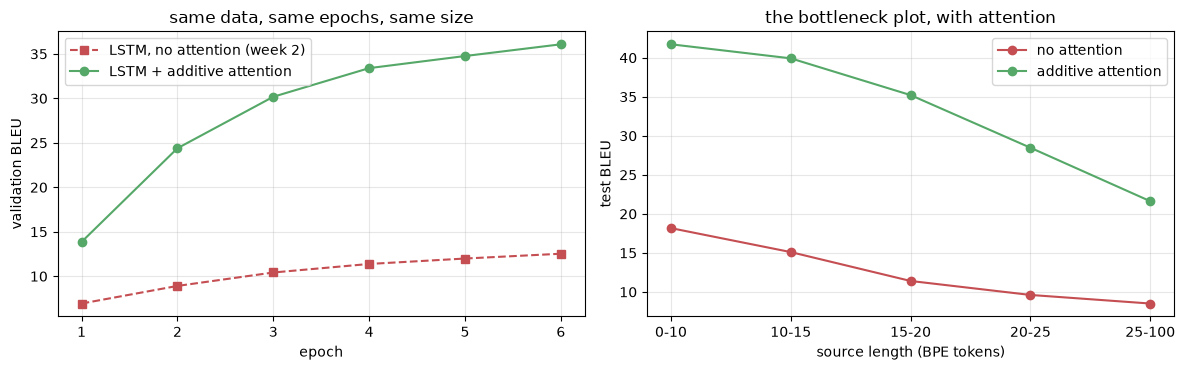

In [15]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.plot(w2_curves["epoch"], w2_curves["val_bleu"], "s--", color="#c44e52", label="LSTM, no attention (week 2)")
a1.plot(attn_curves["additive"]["epoch"], attn_curves["additive"]["val_bleu"], "o-", color="#55a868", label="LSTM + additive attention")
a1.set_xlabel("epoch"); a1.set_ylabel("validation BLEU"); a1.legend(); a1.grid(alpha=.3); a1.set_title("same data, same epochs, same size")
for name, by_len, c in [("no attention", bylen0, "#c44e52"), ("additive attention", attn_bylen["additive"], "#55a868")]:
    xs = list(range(len(by_len)))
    a2.plot(xs, list(by_len.values()), "o-", color=c, label=name); a2.set_xticks(xs); a2.set_xticklabels(list(by_len.keys()))
a2.set_xlabel("source length (BPE tokens)"); a2.set_ylabel("test BLEU"); a2.legend(); a2.grid(alpha=.3); a2.set_title("the bottleneck plot, with attention")
plt.tight_layout(); plt.show()

<!-- REVISE AFTER PRECOMPUTE: the paragraph below describes the expected shape; rewrite it against the real curves. -->

Read the right-hand plot against the bet. The no-attention curve slopes down; the attention curve should be higher *everywhere* and — the actual claim — should slope much less. Long sentences are no longer squeezed through a fixed budget: every decoder step re-reads the source, so the twenty-fifth German token is as available as the first. This is Figure 2 of Bahdanau et al. (2015), on our data. A wider bottleneck raised the line; attention changed its shape.

The same three sentences, now with attention:

In [16]:
show_translations(attn_hyps["additive"])

DE   Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.
REF  A man in an orange hat starring at something.
HYP  A man in an orange hat cooking something.

DE   Ein Boston Terrier läuft über saftig-grünes Gras vor einem weißen Zaun.
REF  A Boston Terrier is running on lush green grass in front of a white fence.
HYP  A muddy-blaan dog is running across the bright green grass.

DE   Fünf Leute in Winterjacken und mit Helmen stehen im Schnee mit Schneemobilen im Hintergrund.
REF  Five people wearing winter jackets and helmets stand in the snow, with snowmobiles in the background.
HYP  Five people in winter jackets and helmets stand in the snow with a snowman in the background.



## 1.4 Alignment that nobody taught

The weights $\alpha_{t,i}$ are numbers we can look at: a row per English token, a column per German token, the weight the decoder put on each source position while producing each target token. The model was never shown which German word corresponds to which English word — only sentence pairs — so whatever structure appears in this matrix was learned as a *by-product* of translating.

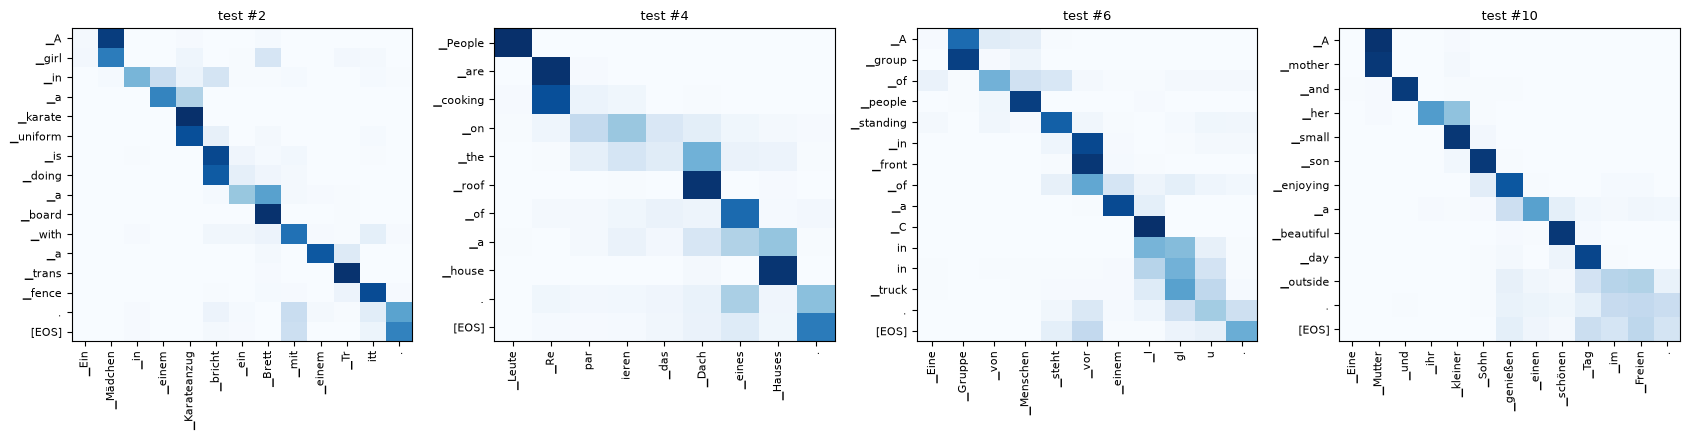

In [17]:
def plot_alignment(w, src_tokens, trg_tokens, ax, title=""):
    # w: (T, S) — rows are target tokens, columns are source tokens
    ax.imshow(w, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(src_tokens))); ax.set_xticklabels(src_tokens, rotation=90, fontsize=8)
    ax.set_yticks(range(len(trg_tokens))); ax.set_yticklabels(trg_tokens, fontsize=8)
    ax.set_title(title, fontsize=9)


@torch.no_grad()
def lstm_alignment(model, i):
    # greedy-translate test sentence i and return its attention matrix with token labels
    s = te_src[i].unsqueeze(0).to(device); s_len = torch.tensor([len(te_src[i])])
    ids, w = model.greedy(s, s_len)
    ids = ids[0].tolist(); n = ids.index(EOS) + 1 if EOS in ids else len(ids)
    trg_tokens = [tok_en.id_to_token(t) for t in ids[:n]]
    src_tokens = [tok_de.id_to_token(t) for t in te_src[i].tolist()]
    return w[0, :n, :len(src_tokens)].cpu().numpy(), src_tokens, trg_tokens


VIZ = [i for i in range(len(te_src)) if 9 <= len(te_src[i]) <= 13][:4]
fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))
for ax, i in zip(axes, VIZ):
    plot_alignment(*lstm_alignment(attn_models["additive"], i), ax, title=f"test #{i}")
plt.tight_layout(); plt.show()

<!-- REVISE AFTER PRECOMPUTE: point at the concrete sentences that came out. -->

Things to look for, and to check on your own sentences:

* **A near-diagonal.** German and English caption word order mostly agree, so most target tokens attend to the source token in the same place. That is expected — the interesting cells are the ones *off* the diagonal.
* **Word-order swaps.** German puts the verb of a subordinate clause at the end (*…, der einen Hut **trägt*** → *who **is wearing** a hat*): the English verb should attend far to the right of where the diagonal would put it. Compound nouns go the other way: one German token feeds several English ones.
* **Function words.** Articles and `[EOS]` often attend diffusely or to the end of the sentence — there is nothing specific in the source to align *the* to, and the model spreads the weight rather than inventing an alignment.

One sentence of caution that we will unpack properly when we open a pretrained model: the map shows where the decoder *looked*, not *why* it chose the word. It is evidence of alignment, not an explanation of the translation. Read it as "there is some kind of relation, but idk what kind".

Question: What does it mean when a German word receives almost no attention from any target position? How would you measure how often that happens, and what would you expect it to correlate with? (Tu et al. 2016 call the fix *coverage*)

# 2. Axis 1 — the score function

There are several options of how to calculate the attention:

| kind | $\mathrm{score}(q, k)$ | parameters | cost | who |
|---|---|---|---|---|
| **additive** (concat) | $v^\top \tanh(W_q q + W_k k)$ | $2\,d\,d_a + d_a$ | a tanh per (query, key) pair — no matmul | Bahdanau et al. 2015 |
| **dot** | $q^\top k$ | 0 | one matmul for the whole batch | Luong et al. 2015 |
| **general** (bilinear) | $q^\top W k$ | $d^2$ | one matmul, plus one | Luong et al. 2015 |
| **scaled dot** | $q^\top k / \sqrt{d_k}$ | 0 | one matmul | Vaswani et al. 2017 |


## 2.1 Why $\sqrt{d_k}$ is a temperature

Four steps.

1. **By definition.** The weights are $\mathrm{softmax}_i(q^\top k_i / \sqrt{d_k})$. Last week's temperature softmax was $\mathrm{softmax}_i(z_i / T)$. Same formula, with $z_i = q^\top k_i$ and $T = \sqrt{d_k}$. Dividing the logits by a constant before the softmax *is* a temperature; the scale does nothing else.
2. **Why that constant.** If the coordinates of $q$ and $k$ are independent with mean 0 and variance 1 — which they are at initialisation — then $q^\top k = \sum_{j=1}^{d_k} q_j k_j$ is a sum of $d_k$ independent terms of variance 1. Its variance is $d_k$; its standard deviation is $\sqrt{d_k}$. At $d_k = 64$ the scores spread over roughly $\pm 8$; at $1\,024$, over $\pm 32$. Nothing about the *content* changed — longer vectors give bigger numbers. Dividing by $\sqrt{d_k}$ puts the standard deviation back to 1 whatever the dimension.
3. **What breaks without it.** Softmax over logits that spread $\pm 32$: the largest is typically tens of units above the second, $e^{30}$ against $e^{0}$, so the biggest key gets weight $\approx 1$ and everything else $\approx 0$. The derivative of the softmax is $p_i(\delta_{ij} - p_j)$, and with one $p = 1$ and the rest $0$ every such product is zero — no gradient reaches the scores, and the model cannot learn to look elsewhere. The same flat region as a saturated sigmoid, for a different reason.
4. **The two limits are two degenerate attentions.** $T \to 0$: softmax → argmax, the weighted sum picks one value — that is hard attention. $T \to \infty$: $\sqrt{d_k}$ puts the model in the middle at the start.

One honest footnote: the scale fixes the temperature *at initialisation only*. The model can learn any other through the norms of $W_Q$ and $W_K$, so the constant conditions training rather than constraining the model. Large models have since made that explicit — QK-norm (Dehghani et al. 2023; Gemma, OLMo) normalises $q$ and $k$ and learns the temperature as a scalar.

In [18]:
seed_all()
n_keys, trials = 30, 200
rows = []
for d in [16, 64, 256, 1024]:
    for scaled in [False, True]:
        ents, grads = [], []
        for _ in range(trials):
            q, K = torch.randn(d), torch.randn(n_keys, d)
            z = (K @ q) / (math.sqrt(d) if scaled else 1.0)
            z.requires_grad_(True)
            p = torch.softmax(z, 0)
            ents.append(-(p * (p + 1e-12).log()).sum().item())
            # gradient of a random downstream loss w.r.t. the logits: how much signal passes back through the softmax
            (p * torch.randn(n_keys)).sum().backward()
            grads.append(z.grad.norm().item())
        rows.append({"d_k": d, "scaled": scaled, "score std": round((torch.randn(1000, d) @ torch.randn(d)).std().item() / (math.sqrt(d) if scaled else 1), 2),
                     "median entropy (max %.2f)" % math.log(n_keys): round(float(np.median(ents)), 2), "median grad norm through softmax": f"{np.median(grads):.1e}"})
pd.DataFrame(rows).set_index(["d_k", "scaled"])

score std  median entropy (max 3.40)  \
d_k  scaled                                         
16   False        3.15                       1.07   
     True         1.01                       3.02   
64   False        6.81                       0.36   
     True         1.11                       2.96   
256  False       15.16                       0.05   
     True         1.03                       2.98   
1024 False       32.87                       0.00   
     True         1.06                       2.97   

            median grad norm through softmax  
d_k  scaled                                   
16   False                           2.1e-01  
     True                            2.1e-01  
64   False                           6.1e-02  
     True                            2.2e-01  
256  False                           5.9e-03  
     True                            2.1e-01  
1024 False                           1.4e-04  
     True                            2.3e-01

Unscaled, the entropy collapses toward zero and the gradient with it, by orders of magnitude as $d_k$ grows; scaled, both are independent of $d_k$. At $d_k = 16$ it barely matters — which is why the RNN-era attention models, with their small scoring spaces, got away without it. The transformer, with $d_k$ in the hundreds, did not.



## 2.2 Three score functions, same everything else

Everything is pretrained (again). Run `precompute.py` if you want to retrain the models.

In [19]:
rows = []
for kind in ["additive", "general", "scaled_dot"]:
    c = attn_curves[kind]
    rows.append({"score": kind, "params": f"{c['n_params'] / 1e6:.2f}M", "test BLEU": round(attn_bleu[kind], 2),
                 "BLEU 0-10": attn_bylen[kind].get("0-10"), "BLEU 25+": attn_bylen[kind].get("25-100"),
                 "s/epoch": round(epoch_seconds(c["seconds"])), "val BLEU by epoch": c["val_bleu"]})
    if kind != "additive":
        record(f"LSTM + {kind} attention", c["n_params"], attn_bleu[kind], attn_bylen[kind],
               s_per_epoch=epoch_seconds(c["seconds"]), note="Luong 2015" if kind == "general" else "Vaswani 2017 scoring")
pd.DataFrame(rows).set_index("score")

,params,test BLEU,BLEU 0-10,BLEU 25+,s/epoch,val BLEU by epoch
score,,,,,,
additive,8.72M,36.29,41.72,21.62,59,"[13.86, 24.39, 30.18, 33.4, 34.76, 36.08]"
general,8.65M,19.08,24.99,10.98,51,"[7.55, 11.52, 14.36, 17.05, 18.03, 18.4]"
scaled_dot,8.58M,36.68,44.14,23.01,72,"[15.65, 27.17, 31.51, 34.12, 34.97, 35.98]"


# 3. Axes 2 and 3 — what attends to what, and over which set

## 3.1 Cross, self, causal

Three cases of one formula:

* **Cross-attention** — queries from one sequence (en), keys and values from another (de). The decoder reading the encoder.
* **Self-attention** — $Q$, $K$ and $V$ all from the same sequence (for example, en): every position gathers a context from every other position. This is the one that replaces recurrence.
* **Masked (causal) self-attention** — self-attention where position $t$ is forbidden to look at positions $> t$. Without the mask, position $t$ would simply read the answer at $t+1$ from the gold sequence, learn nothing, and have nothing to read at generation time.

Masks are just boolean matrices, and it is worth seeing them once as pictures. A padding mask says which *keys* are real tokens; a causal mask says which *keys* are in the past; a decoder's self-attention uses both.

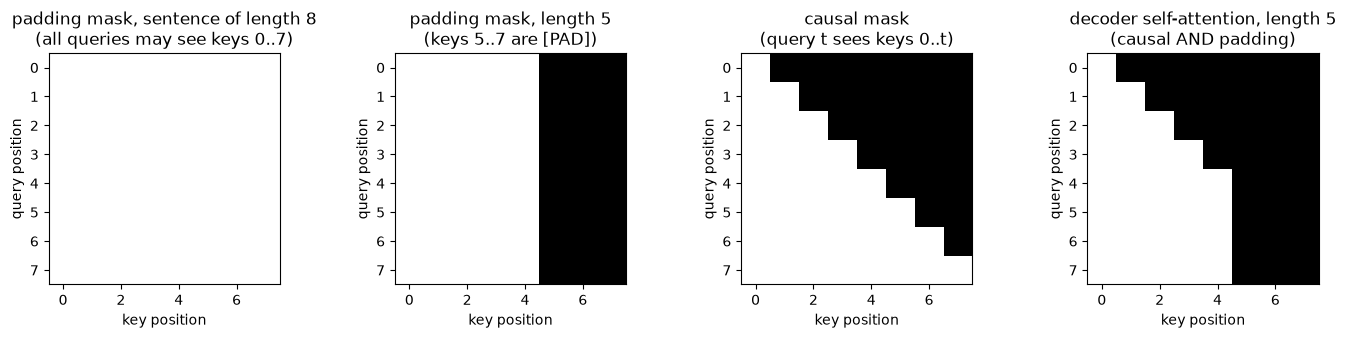

In [20]:
lens = [5, 8, 3]; S = max(lens)
pad_mask = torch.zeros(len(lens), S, dtype=torch.bool)
for b, l in enumerate(lens): pad_mask[b, :l] = True
causal = torch.tril(torch.ones(S, S, dtype=torch.bool))

fig, axes = plt.subplots(1, 4, figsize=(14, 3.3))
axes[0].imshow(pad_mask[:, None, :].expand(-1, S, -1)[1], cmap="Greys_r", vmin=0, vmax=1); axes[0].set_title("padding mask, sentence of length 8\n(all queries may see keys 0..7)")
axes[1].imshow(pad_mask[:, None, :].expand(-1, S, -1)[0], cmap="Greys_r", vmin=0, vmax=1); axes[1].set_title("padding mask, length 5\n(keys 5..7 are [PAD])")
axes[2].imshow(causal, cmap="Greys_r", vmin=0, vmax=1); axes[2].set_title("causal mask\n(query t sees keys 0..t)")
axes[3].imshow(causal & pad_mask[0][None, :], cmap="Greys_r", vmin=0, vmax=1); axes[3].set_title("decoder self-attention, length 5\n(causal AND padding)")
for ax in axes: ax.set_xlabel("key position"); ax.set_ylabel("query position")
plt.tight_layout(); plt.show()

White = may attend, black = masked. In the code, black cells get $-10^9$ added to their score before the softmax, so their weight is exactly zero after it.


# 4. The transformer, from scratch

We now have every conceptual piece. Vaswani et al. (2017) asked: if attention is what fixed the encoder–decoder, and self-attention has a path length of one — why keep the LSTM at all? The answer was a model made of nothing but attention, feed-forward layers and the plumbing needed to make that trainable. We build it piece by piece. Every piece gets one sentence of "why it is there" and one check.


## 4.1 Scaled dot-product attention — the function

Queries, keys and values are batched tensors; the mask is a boolean tensor broadcastable to `(..., T, S)`; the output is the weighted sum and the weights themselves (we will want to look at them).

In [27]:
def attention(q, k, v, mask=None, dropout=None):
    """Scaled dot-product attention (Vaswani et al. 2017), the whole thing.
    q: (..., T, d_k)  k: (..., S, d_k)  v: (..., S, d_v)
    mask: broadcastable to (..., T, S), True = may attend."""
    
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.size(-1))
    if mask is not None:
        scores = scores.masked_fill(~mask, -1e9)
    w = torch.softmax(scores, dim=-1)
    if dropout is not None:
        w = dropout(w)
    return w @ v, w

In [28]:
# a check against PyTorch's own implementation, the one production models call
seed_all()
q, k, v = (torch.randn(2, 4, 7, 32) for _ in range(3))
mask = torch.rand(2, 1, 7, 7) > 0.3
mask[..., 0] = True                                   # no fully masked row (that would be NaN in both)
ours, _ = attention(q, k, v, mask)
theirs = nn.functional.scaled_dot_product_attention(q, k, v, attn_mask=mask)
check("our attention == F.scaled_dot_product_attention", torch.allclose(ours, theirs, atol=1e-5))

✓ our attention == F.scaled_dot_product_attention


## 4.2 Multi-head attention

One softmax produces one weighted average per query — one "pattern" of where to look. But a token has several relationships worth looking up at once: the word it agrees with, the word it modifies, the previous token. So the transformer runs $h$ attentions in parallel, each in its own $d/h$-dimensional subspace, and concatenates the results. The cost is the same as one attention of width $d$ (the projections are just sliced), and each head is free to learn a different lookup.

In [29]:
class MultiHeadAttention(nn.Module):
    """h heads of size d/h, run as one batched matmul. Returns the output and the (B, h, T, S) weights."""

    def __init__(self, d, h, dropout=0.1):
        super().__init__()
        assert d % h == 0
        self.h, self.d_k = h, d // h
        self.W_q, self.W_k, self.W_v, self.W_o = (nn.Linear(d, d) for _ in range(4))
        self.drop = nn.Dropout(dropout)

    def forward(self, q_in, k_in, v_in, mask=None):
        B, T, d = q_in.shape
        S = k_in.size(1)
        q = self.W_q(q_in).view(B, T, self.h, self.d_k).transpose(1, 2)    # (B, h, T, d_k)
        k = self.W_k(k_in).view(B, S, self.h, self.d_k).transpose(1, 2)    # (B, h, S, d_k)
        v = self.W_v(v_in).view(B, S, self.h, self.d_k).transpose(1, 2)    # (B, h, S, d_k)
        out, w = attention(q, k, v, mask, self.drop)                       # (B, h, T, d_k), (B, h, T, S)
        out = out.transpose(1, 2).reshape(B, T, d)                         # heads back side by side
        return self.W_o(out), w

In [30]:
mha = MultiHeadAttention(d=256, h=8).eval()            # eval: no attention dropout, so the rows sum to one
x = torch.randn(3, 10, 256)                            # batch of 3, sequence of 10
out, w = mha(x, x, x)
print(f"input {tuple(x.shape)} -> output {tuple(out.shape)}, weights {tuple(w.shape)}  (B, heads, queries, keys)")
check("the weights sum to one over keys", torch.allclose(w.sum(-1), torch.ones(3, 8, 10)))
show_params("multi-head attention, d=256, h=8", mha, Q=mha.W_q, K=mha.W_k, V=mha.W_v, O=mha.W_o)   # each 256 x 256 + 256

input (3, 10, 256) -> output (3, 10, 256), weights (3, 8, 10, 10)  (B, heads, queries, keys)
✓ the weights sum to one over keys
multi-head attention, d=256, h=8: 263,168 parameters   |   Q 65,792 (25%)   K 65,792 (25%)   V 65,792 (25%)   O 65,792 (25%)


## 4.3 Positions: attention is a set operation

Here is the thing the formula does not have and an RNN has for free: *order*. Attention scores each key against the query by content alone; the sum over keys does not care where they were. Permute the input tokens and you permute the outputs the same way — nothing else changes. A self-attention encoder without positional information is a **bag of words**.


In [31]:
class PositionalEncoding(nn.Module):
    """kind: 'sin' (Vaswani), 'learned' (BERT/GPT-2), 'none' (the ablation)."""

    def __init__(self, d, max_len=64, kind="sin", dropout=0.1):
        super().__init__()
        self.kind = kind
        self.drop = nn.Dropout(dropout)
        if kind == "sin":
            pos = torch.arange(max_len).unsqueeze(1).float()
            freq = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
            pe = torch.zeros(max_len, d)
            pe[:, 0::2] = torch.sin(pos * freq)
            pe[:, 1::2] = torch.cos(pos * freq)
            self.register_buffer("pe", pe)
        elif kind == "learned":
            self.pe = nn.Parameter(torch.randn(max_len, d) * 0.02)
        elif kind != "none":
            raise ValueError(kind)

    def forward(self, x):
        if self.kind != "none":
            x = x + self.pe[: x.size(1)]
        return self.drop(x)


class FeedForward(nn.Module):
    """Position-wise MLP: the same two layers applied to every position independently."""

    def __init__(self, d, ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, ff), nn.ReLU(), nn.Dropout(dropout), nn.Linear(ff, d))

    def forward(self, x):
        return self.net(x)


class EncoderLayer(nn.Module):
    """Pre-LN: x + SelfAttn(LN(x));  x + FFN(LN(x))."""

    def __init__(self, d, h, ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d, h, dropout)
        self.ffn = FeedForward(d, ff, dropout)
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        y = self.ln1(x)
        a, w = self.self_attn(y, y, y, mask)
        x = x + self.drop(a)
        x = x + self.drop(self.ffn(self.ln2(x)))
        return x, w

In [32]:
seed_all()
layer = EncoderLayer(d=64, h=4, ff=128, dropout=0.0).eval()
x = torch.randn(1, 6, 64)
perm = torch.tensor([3, 0, 5, 1, 4, 2])
y, _ = layer(x, None)
y_perm, _ = layer(x[:, perm], None)
check("permute the input -> the output is permuted the same way", torch.allclose(y[:, perm], y_perm, atol=1e-5))

✓ permute the input -> the output is permuted the same way


So order has to be *injected*, and the only place to inject it is the input: add to each token embedding a vector that depends on its position. Three ways to make that vector, and they are the three the field has used in order:

* **Sinusoidal** (Vaswani 2017). Position $p$, dimension $2i$ and $2i+1$: $PE_{p,2i} = \sin(p / 10000^{2i/d})$, $PE_{p,2i+1} = \cos(p / 10000^{2i/d})$. Each pair of dimensions is a clock hand rotating at its own frequency: fast hands in the low dimensions resolve neighbouring positions, slow hands in the high ones resolve the coarse location. The property that makes this more than a lookup table: for any offset $k$, $PE_{p+k}$ is a *linear* function of $PE_p$ (a rotation by $k$ steps of every clock hand, independent of $p$), so a linear layer can learn "the token three positions back" without knowing $p$.
* **Learned** (BERT, GPT-2). A table of $L_{\max} \times d$ free parameters. Simpler, slightly better in-distribution, and it cannot say anything about position $L_{\max} + 1$ — it has never seen it.
* **Relative / rotary** (Shaw et al. 2018; RoPE, Su et al. 2021; ALiBi, Press et al. 2021). Put the position into the *score* rather than the input: $\mathrm{score}(q_i, k_j)$ depends on $i - j$. RoPE does it by rotating $q$ and $k$ by angles proportional to their positions before the dot product, so the product depends only on the difference. This is what current LLMs use -- we'll talk about it a few weeks later, promise.

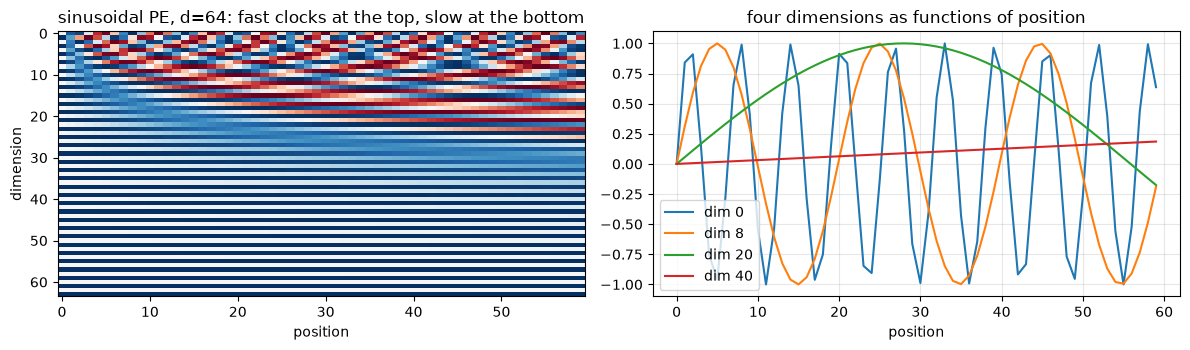

In [33]:
pe = PositionalEncoding(d=64, max_len=60, kind="sin", dropout=0.0).pe.numpy()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
a1.imshow(pe.T, aspect="auto", cmap="RdBu"); a1.set_xlabel("position"); a1.set_ylabel("dimension"); a1.set_title("sinusoidal PE, d=64: fast clocks at the top, slow at the bottom")
for i in [0, 8, 20, 40]:
    a2.plot(pe[:, i], label=f"dim {i}")
a2.set_xlabel("position"); a2.legend(); a2.grid(alpha=.3); a2.set_title("four dimensions as functions of position")
plt.tight_layout(); plt.show()

## 4.4 The rest of the layer: residual, LayerNorm, FFN, dropout

An encoder layer is attention plus three things that have nothing to do with attention and everything to do with making a deep stack trainable:

* **Residual connections** (He et al. 2016): $x + \mathrm{Sublayer}(x)$. Without them a 6-layer stack does not train. Think of it as of the facilitator for the concept "the word on step k, is a combination of itself on step k-1 and a combination of the other words we paid attention on this step"
* **LayerNorm** (Ba et al. 2016), not BatchNorm: normalise each position's vector over its $d$ features, so we can have a deep model.
* **The feed-forward block**: a two-layer MLP, $d \to 4d \to d$, applied to every position *independently*. Attention decides what to gather from other positions; the FFN decides what to do with it.
* **Dropout** on the attention weights, on each sublayer's output and on the embeddings.

In [34]:
class DecoderLayer(nn.Module):
    """Pre-LN: causal self-attention, then cross-attention over the encoder memory, then FFN."""

    def __init__(self, d, h, ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d, h, dropout)
        self.cross_attn = MultiHeadAttention(d, h, dropout)
        self.ffn = FeedForward(d, ff, dropout)
        self.ln1, self.ln2, self.ln3 = nn.LayerNorm(d), nn.LayerNorm(d), nn.LayerNorm(d)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, memory, trg_mask, mem_mask):
        y = self.ln1(x)
        a, w_self = self.self_attn(y, y, y, trg_mask)
        x = x + self.drop(a)
        a, w_cross = self.cross_attn(self.ln2(x), memory, memory, mem_mask)
        x = x + self.drop(a)
        x = x + self.drop(self.ffn(self.ln3(x)))
        return x, w_self, w_cross

In [35]:
enc = EncoderLayer(d=256, h=8, ff=1024)
show_params("one encoder layer, d=256, ff=1024", enc, attention=enc.self_attn, FFN=enc.ffn, LayerNorm=(enc.ln1, enc.ln2))

one encoder layer, d=256, ff=1024: 789,760 parameters   |   attention 263,168 (33%)   FFN 525,568 (67%)   LayerNorm 1,024 (0%)


## 4.5 Assembly

Embeddings scaled by $\sqrt d$ (so that they are not drowned by the positional encoding, whose entries are of order 1), positional encoding, $N$ encoder layers, $N$ decoder layers, a final LayerNorm on each side, and an output projection that shares its weights with the target embedding. The decoder's output at position $t$ is the distribution over the token at $t+1$: the same next-token prediction as every model since week 2.

In [36]:
class Transformer(nn.Module):
    """Encoder-decoder transformer (Vaswani et al. 2017), Pre-LN variant, tied target embeddings.
      pe     'sin' | 'learned' | 'none'
      cross  'full'   — the decoder attends to every encoder state (the real thing)
             'pooled' — the decoder sees one mean-pooled encoder vector: the week-2 bottleneck, rebuilt
    forward() returns logits and keeps every layer's attention weights in self.attn for inspection."""

    def __init__(self, src_vocab, trg_vocab, d=256, h=8, ff=1024, layers=6, dropout=0.1,
                 pe="sin", cross="full", max_len=64):
        super().__init__()
        self.d, self.cross = d, cross
        self.src_emb = nn.Embedding(src_vocab, d, padding_idx=PAD)
        self.trg_emb = nn.Embedding(trg_vocab, d, padding_idx=PAD)
        self.pos = PositionalEncoding(d, max_len, pe, dropout)
        self.enc_layers = nn.ModuleList(EncoderLayer(d, h, ff, dropout) for _ in range(layers))
        self.dec_layers = nn.ModuleList(DecoderLayer(d, h, ff, dropout) for _ in range(layers))
        self.ln_enc, self.ln_dec = nn.LayerNorm(d), nn.LayerNorm(d)
        self.out = nn.Linear(d, trg_vocab, bias=False)
        self.out.weight = self.trg_emb.weight                      # weight tying (Press & Wolf 2017)
        self.attn = {}
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    @staticmethod
    def causal_mask(T, device):
        return torch.tril(torch.ones(T, T, dtype=torch.bool, device=device))     # (T, T)

    def encode(self, src):
        mask = (src != PAD)[:, None, None, :]                       # (B, 1, 1, S): keys that are real tokens
        x = self.pos(self.src_emb(src) * math.sqrt(self.d))
        ws = []
        for layer in self.enc_layers:
            x, w = layer(x, mask)
            ws.append(w)
        memory = self.ln_enc(x)
        if self.cross == "pooled":                                  # the ablation: one vector, like week 2
            m = mask[:, 0, 0, :, None].float()
            memory = (memory * m).sum(1, keepdim=True) / m.sum(1, keepdim=True)   # (B, 1, d)
            mask = torch.ones_like(mask[:, :, :, :1])
        self.attn["enc"] = ws
        return memory, mask

    def decode(self, trg_in, memory, mem_mask):
        T = trg_in.size(1)
        trg_mask = self.causal_mask(T, trg_in.device)[None, None] & (trg_in != PAD)[:, None, None, :]
        x = self.pos(self.trg_emb(trg_in) * math.sqrt(self.d))
        ws, wc = [], []
        for layer in self.dec_layers:
            x, w_self, w_cross = layer(x, memory, trg_mask, mem_mask)
            ws.append(w_self)
            wc.append(w_cross)
        self.attn["dec_self"], self.attn["dec_cross"] = ws, wc
        return self.out(self.ln_dec(x))                             # (B, T, V)

    def forward(self, src, src_len, trg_in):
        # the whole target sequence in ONE forward pass: no loop over time (that is what the causal mask buys)
        memory, mem_mask = self.encode(src)
        return self.decode(trg_in, memory, mem_mask)

    @torch.no_grad()
    def greedy(self, src, src_len, max_len=40):
        memory, mem_mask = self.encode(src)                         # the encoder runs once
        ys = torch.full((src.size(0), 1), BOS, dtype=torch.long, device=src.device)
        done = torch.zeros(src.size(0), dtype=torch.bool, device=src.device)
        for _ in range(max_len):
            logits = self.decode(ys, memory, mem_mask)              # the decoder re-reads the growing prefix
            y = logits[:, -1].argmax(-1, keepdim=True).masked_fill(done.unsqueeze(1), PAD)
            ys = torch.cat([ys, y], dim=1)
            done |= y.squeeze(1) == EOS
            if done.all():
                break
        return ys[:, 1:]

In [37]:
tf_demo = Transformer(V_DE, V_EN, d=256, h=8, ff=1024, layers=6)
show_params("our transformer, 6 encoder + 6 decoder layers", tf_demo,
            layers=(tf_demo.enc_layers, tf_demo.dec_layers), embeddings=(tf_demo.src_emb, tf_demo.trg_emb))

ref = nn.Transformer(d_model=256, nhead=8, num_encoder_layers=6, num_decoder_layers=6, dim_feedforward=1024,
                     norm_first=True, batch_first=True)
check("the stack is torch.nn.Transformer(norm_first=True), to the parameter",
      n_params(tf_demo.enc_layers, tf_demo.dec_layers, tf_demo.ln_enc, tf_demo.ln_dec) == n_params(ref))
del ref

our transformer, 6 encoder + 6 decoder layers: 15,156,224 parameters   |   layers 11,059,200 (73%)   embeddings 4,096,000 (27%)   other 1,024 (0%)
✓ the stack is torch.nn.Transformer(norm_first=True), to the parameter


The embeddings are a quarter of the model: two vocabularies of 8 000 at $d = 256$. That ratio flips in real models, where the layers dominate; at our size the vocabulary is expensive.


## 4.6 Training: the whole target in one pass

Two things the paper introduced that are easy to dismiss as tuning and are not:

* **Warmup.** The learning rate rises linearly for the first few hundred steps, then decays as $1/\sqrt{\text{step}}$. With Post-LN this is mandatory — without it the model diverges in the first hundred updates. Pre-LN survives without warmup, but still trains better with it; we keep a short one. In code it is one factor function handed to `torch.optim.lr_scheduler.LambdaLR` — no custom scheduler class.
* **Label smoothing** ($\epsilon = 0.1$): the target distribution is $0.9$ on the gold token and $0.1$ spread over the rest. Vaswani et al. note that it *hurts perplexity and improves BLEU* — the model is trained to be less sure, which makes its argmax better calibrated. That is a week-2 "number that lies" in a new coat: the loss you optimise and the metric you care about disagree.

In [38]:
def lr_scale(step, warmup):
    """The transformer schedule (Vaswani et al. 2017), as a factor on the peak lr:
    linear warmup for `warmup` steps, then 1 / sqrt(step). `step` counts from 1."""
    return min(step / warmup, math.sqrt(warmup / step))


def train_transformer(model, data, device, epochs, eval_fn, peak_lr=7e-4, warmup=800, batch_size=64,
                      label_smoothing=0.1, clip=1.0):
    """eval_fn(model) -> (score, name) on the validation set, e.g. BLEU or word accuracy."""
    (tr_src, tr_trg), (va_src, va_trg, _) = data
    opt = torch.optim.Adam(model.parameters(), lr=peak_lr, betas=(0.9, 0.98), eps=1e-9)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda step: lr_scale(step + 1, warmup))   # scales peak_lr
    curves = {"epoch": [], "train_loss": [], "val_loss": [], "val_score": [], "seconds": [], "lr": []}
    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        tot, n = 0.0, 0
        for s, s_len, t in s2s_batches(tr_src, tr_trg, batch_size, shuffle=True, device=device):
            logits = model(s, s_len, t[:, :-1])
            loss = nn.functional.cross_entropy(logits.reshape(-1, logits.size(-1)), t[:, 1:].reshape(-1),
                                               ignore_index=PAD, label_smoothing=label_smoothing)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            sched.step()
            k = (t[:, 1:] != PAD).sum().item()
            tot += loss.item() * k
            n += k
        lr = sched.get_last_lr()[0]
        vloss = val_loss(model, va_src, va_trg, device)             # plain cross-entropy, no smoothing
        score, name = eval_fn(model)
        curves["epoch"].append(ep)
        curves["train_loss"].append(round(tot / n, 4))
        curves["val_loss"].append(round(vloss, 4))
        curves["val_score"].append(round(score, 2))
        curves["seconds"].append(round(time.time() - t0, 1))
        curves["lr"].append(lr)
        log(f"epoch {ep}: train loss {tot / n:.3f}  val loss {vloss:.3f}  val {name} {score:.2f}  "
            f"lr {lr:.2e}  ({time.time() - t0:.0f}s)")
    curves["score_name"] = name
    return curves

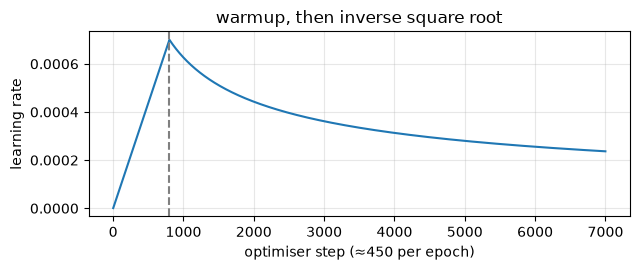

In [39]:
steps = np.arange(1, 7000)
lr = [7e-4 * lr_scale(s, warmup=800) for s in steps]
plt.figure(figsize=(6.5, 2.8)); plt.plot(steps, lr); plt.axvline(800, ls="--", color="gray")
plt.xlabel("optimiser step (≈450 per epoch)"); plt.ylabel("learning rate"); plt.title("warmup, then inverse square root"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

We'll train one epoch on the same 5 000 pairs the attention LSTM trained on in 1.3, with a 3-layer transformer, so we can make sure it works.

In [40]:
seed_all()
tf_live = Transformer(V_DE, V_EN, d=256, h=8, ff=1024, layers=3).to(device)
print(f"parameters: {n_params(tf_live) / 1e6:.2f}M")
t = time.time()
tf_live_curves = train_transformer(tf_live, ((tr_src[:LIVE_PAIRS], tr_trg[:LIVE_PAIRS]), (va_src, va_trg, va_en)), device, LIVE_EPOCHS,
                                   eval_fn=lambda m: (s2s_bleu(m, tok_en, va_src, va_trg, va_en, device)[0], "BLEU"), warmup=40)
print(f"{time.time() - t:.0f}s per epoch on {LIVE_PAIRS:,} pairs — attention LSTM took {live_curves['seconds'][-1] / LIVE_EPOCHS:.0f}s on the same data")

parameters: 9.63M
epoch 1: train loss 6.729  val loss 5.097  val BLEU 1.12  lr 4.95e-04  (38s)
38s per epoch on 5,000 pairs — attention LSTM took 56s on the same data


Now the real ones. `precompute.py` trained 1, 3 and 6 layers — same width, same 15 epochs — and two ablations at 6 layers.

In [41]:
if RECOMPUTE:
    !python precompute.py --only transformer ablations

tf_curves = json.load(open(f"{ART_DIR}/transformer_curves.json"))
tf_curves.update(json.load(open(f"{ART_DIR}/ablation_curves.json")))
tf_models, tf_bleu, tf_bylen, tf_hyps = {}, {}, {}, {}
labels = {"l1": "Transformer, 1 layer", "l3": "Transformer, 3 layers", "l6": "Transformer, 6 layers",
          "no_ca": "Transformer, 6 layers, no cross-attention", "no_pe": "Transformer, 6 layers, no positions"}
for name in ["l1", "l3", "l6", "no_ca", "no_pe"]:
    cfg = {k: v for k, v in tf_curves[name]["config"].items() if k != "epochs"}
    m = load_weights(Transformer(V_DE, V_EN, **cfg), f"{ART_DIR}/transformer_{name}.pt", device)
    t = time.time()
    b, h = s2s_bleu(m, tok_en, te_src, te_trg, te_en, device)
    tf_models[name], tf_bleu[name], tf_hyps[name] = m, b, h
    tf_bylen[name] = bleu_by_src_len(h, te_en, te_src)
    ep = tf_curves[name]["config"]["epochs"]
    record(labels[name], tf_curves[name]["n_params"], b, tf_bylen[name], s_per_epoch=epoch_seconds(tf_curves[name]["seconds"]),
           note=f"{ep} epochs" + (", mean-pooled memory" if name == "no_ca" else ", pe=none" if name == "no_pe" else ""))
    print(f"{labels[name]:45s} test BLEU {b:5.2f}   by length {tf_bylen[name]}   ({time.time() - t:.0f}s)")

Transformer, 1 layer                          test BLEU 39.18   by length {'0-10': 45.28, '10-15': 42.26, '15-20': 37.65, '20-25': 34.07, '25-100': 23.95}   (124s)
Transformer, 3 layers                         test BLEU 40.11   by length {'0-10': 46.62, '10-15': 43.35, '15-20': 38.43, '20-25': 31.49, '25-100': 28.59}   (51s)
Transformer, 6 layers                         test BLEU 40.05   by length {'0-10': 47.53, '10-15': 42.97, '15-20': 38.45, '20-25': 32.89, '25-100': 27.98}   (47s)
Transformer, 6 layers, no cross-attention     test BLEU 26.13   by length {'0-10': 38.56, '10-15': 29.7, '15-20': 22.07, '20-25': 17.07, '25-100': 12.95}   (13s)
Transformer, 6 layers, no positions           test BLEU 31.68   by length {'0-10': 43.07, '10-15': 34.8, '15-20': 29.35, '20-25': 20.38, '25-100': 15.31}   (12s)


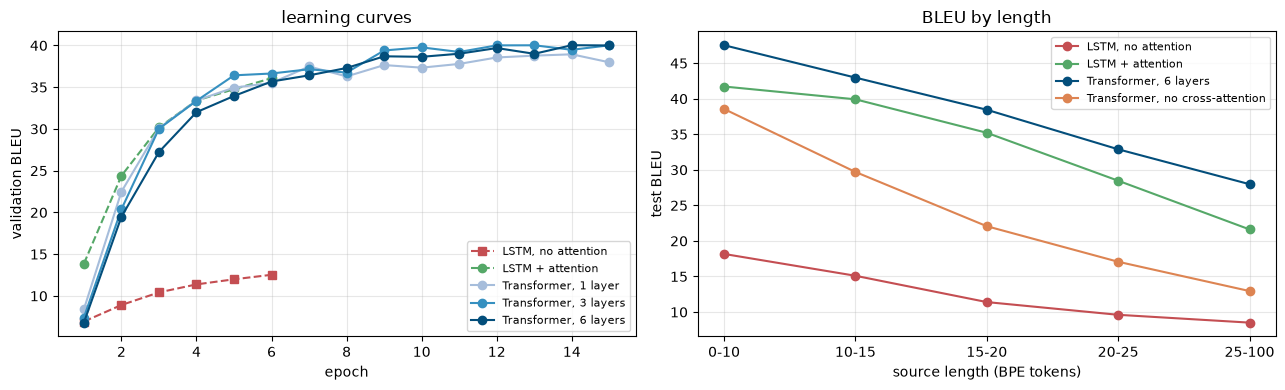

,params,test BLEU,BLEU 0-10,BLEU 25+,s/epoch,note
model,,,,,,
"LSTM, no attention (week 2)",8.0M,13.4,18.17,8.51,167,one vector between the halves
LSTM + additive attention,8.7M,36.3,41.72,21.62,59,"6 epochs, Bahdanau 2015"
LSTM + general attention,8.6M,19.1,24.99,10.98,51,Luong 2015
LSTM + scaled_dot attention,8.6M,36.7,44.14,23.01,72,Vaswani 2017 scoring
"Transformer, 1 layer",5.9M,39.2,45.28,23.95,34,15 epochs
"Transformer, 3 layers",9.6M,40.1,46.62,28.59,54,15 epochs
"Transformer, 6 layers",15.2M,40.1,47.53,27.98,80,15 epochs
"Transformer, 6 layers, no cross-attention",15.2M,26.1,38.56,12.95,81,"15 epochs, mean-pooled memory"
"Transformer, 6 layers, no positions",15.2M,31.7,43.07,15.31,73,"15 epochs, pe=none"


In [42]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(w2_curves["epoch"], w2_curves["val_bleu"], "s--", color="#c44e52", label="LSTM, no attention")
a1.plot(attn_curves["additive"]["epoch"], attn_curves["additive"]["val_bleu"], "o--", color="#55a868", label="LSTM + attention")
for name, c in [("l1", "#a6bddb"), ("l3", "#3690c0"), ("l6", "#034e7b")]:
    a1.plot(tf_curves[name]["epoch"], tf_curves[name]["val_score"], "o-", color=c, label=labels[name])
a1.set_xlabel("epoch"); a1.set_ylabel("validation BLEU"); a1.legend(fontsize=8); a1.grid(alpha=.3); a1.set_title("learning curves")
for name, by_len, c in [("LSTM, no attention", bylen0, "#c44e52"), ("LSTM + attention", attn_bylen["additive"], "#55a868"),
                        ("Transformer, 6 layers", tf_bylen["l6"], "#034e7b"), ("Transformer, no cross-attention", tf_bylen["no_ca"], "#dd8452")]:
    xs = list(range(len(by_len))); a2.plot(xs, list(by_len.values()), "o-", color=c, label=name); a2.set_xticks(xs); a2.set_xticklabels(list(by_len.keys()))
a2.set_xlabel("source length (BPE tokens)"); a2.set_ylabel("test BLEU"); a2.legend(fontsize=8); a2.grid(alpha=.3); a2.set_title("BLEU by length")
plt.tight_layout(); plt.show()
show_results()

<!-- REVISE AFTER PRECOMPUTE: every claim below is an expectation; rewrite against the table that came out. -->

## 4.7 Reading the table

Read it as three separate experiments, because there are three parameters.

**Depth.** On one hand -- the deeper, the bigger the model -- the better, but for deeper models we also need more data, so something might go a little bit different than we expected.

**No cross-attention.** Expect a large drop *and the slope to come back* in the right-hand plot. This is the ablation that says where the transformer's gain comes from: not from self-attention as such — that model has all of it — but from the decoder's access to every source position.

**No positions.** Same model, no positional encoding. Expect a clear drop, but not to zero.

In [43]:
print("--- 6 layers ---"); show_translations(tf_hyps["l6"])
print("--- 6 layers, no positional encoding ---"); show_translations(tf_hyps["no_pe"])

--- 6 layers ---
DE   Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.
REF  A man in an orange hat starring at something.
HYP  A man in an orange hat is checking something.

DE   Ein Boston Terrier läuft über saftig-grünes Gras vor einem weißen Zaun.
REF  A Boston Terrier is running on lush green grass in front of a white fence.
HYP  A body of pants runs across a white and green grass in front of a white fence.

DE   Fünf Leute in Winterjacken und mit Helmen stehen im Schnee mit Schneemobilen im Hintergrund.
REF  Five people wearing winter jackets and helmets stand in the snow, with snowmobiles in the background.
HYP  Five people in winter jackets and helmets are standing in the snow with a snowman in the background.

--- 6 layers, no positional encoding ---
DE   Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.
REF  A man in an orange hat starring at something.
HYP  A man in an orange hat is about to light on a ride something.

DE   Ein Boston Terrier läuft über saf

# 5. Looking inside our model

Only our own model today; what the heads of a *pretrained* model do — and how much of that is real — is a topic for when we open one. But our 6-layer translator has 48 cross-attention heads and 48 self-attention heads on each side, and the block-1 alignment picture is in there somewhere.

## 5.1 Cross-attention, by layer and head

For one test sentence: the decoder's cross-attention weights, one panel per (layer, head), rows are the produced English tokens, columns the German source.

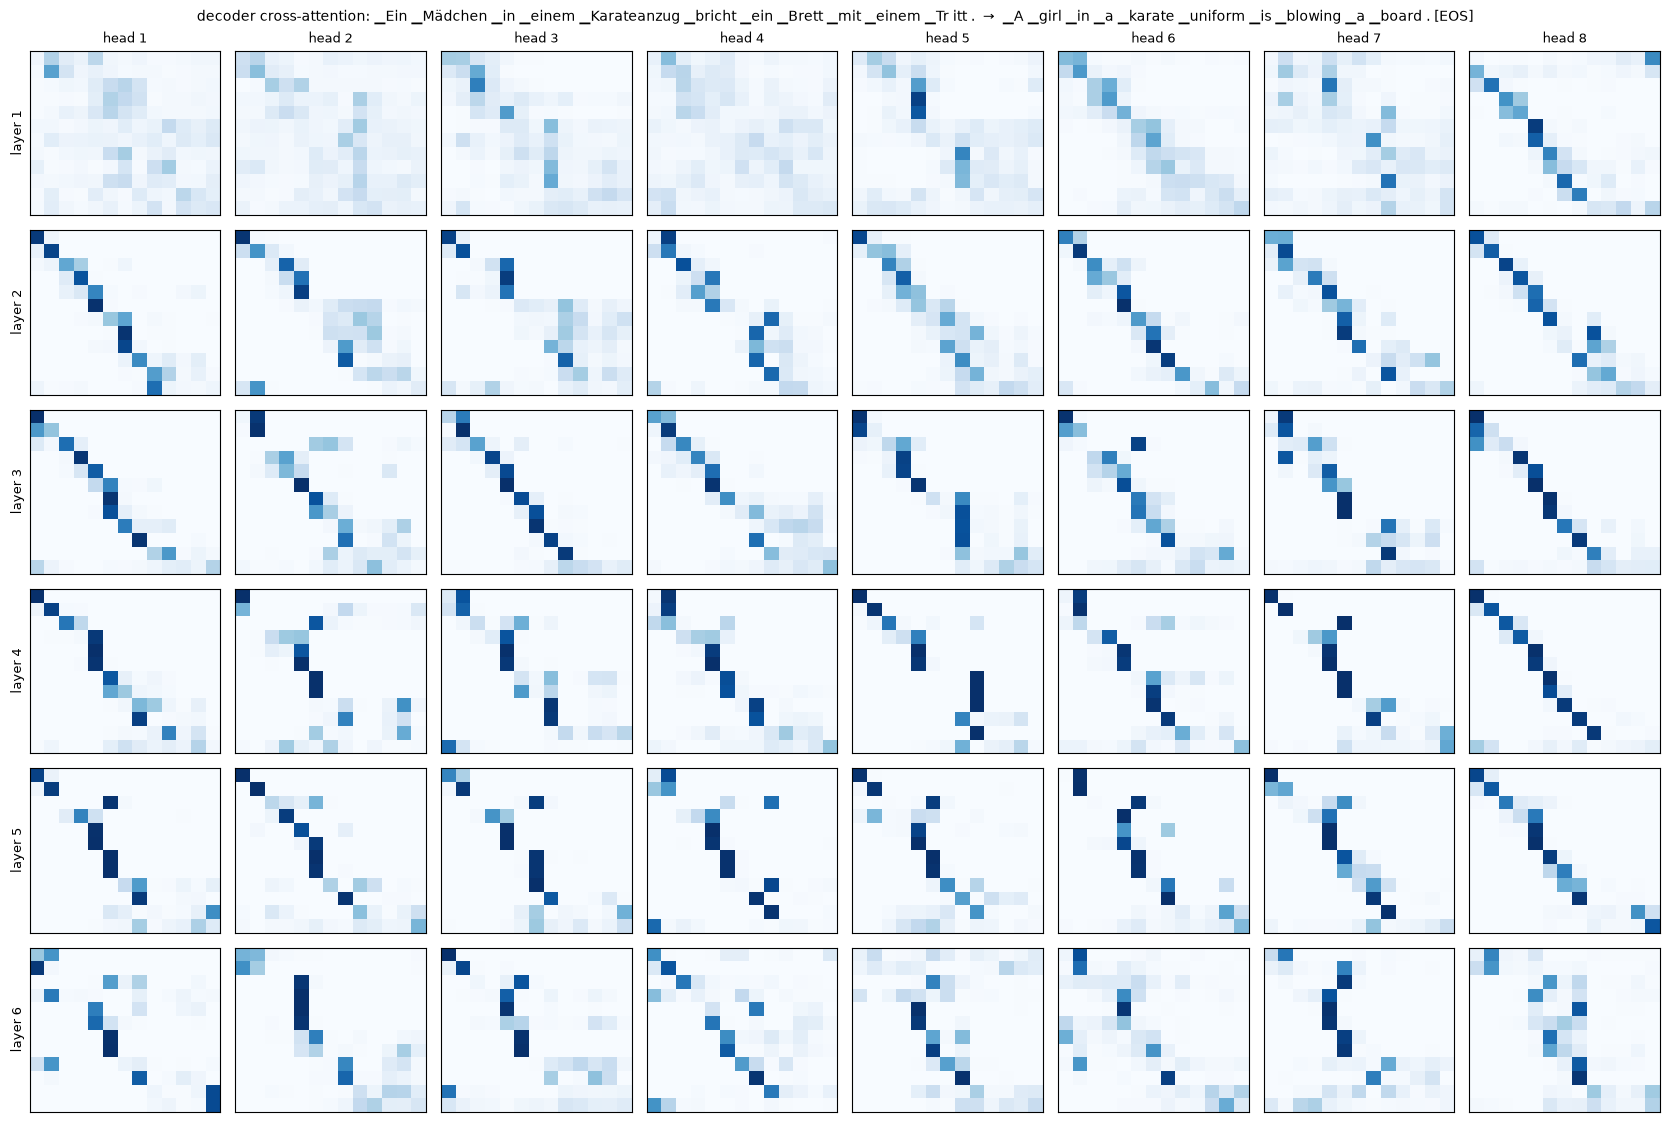

In [44]:
@torch.no_grad()
def tf_attention_maps(model, i):
    # greedy-translate test sentence i, then run one teacher-forced pass on the model's own output to read every layer's weights
    s = te_src[i].unsqueeze(0).to(device); s_len = torch.tensor([len(te_src[i])])
    ids = model.greedy(s, s_len)[0].tolist()
    n = ids.index(EOS) + 1 if EOS in ids else len(ids)
    trg_in = torch.tensor([[BOS] + ids[:n - 1]], device=device)
    model(s, s_len, trg_in)
    src_tokens = [tok_de.id_to_token(t) for t in te_src[i].tolist()]
    trg_tokens = [tok_en.id_to_token(t) for t in ids[:n]]
    return {k: [w[0].cpu().numpy() for w in v] for k, v in model.attn.items()}, src_tokens, trg_tokens


maps, s_tok, t_tok = tf_attention_maps(tf_models["l6"], VIZ[0])
n_layers, n_heads = len(maps["dec_cross"]), maps["dec_cross"][0].shape[0]
fig, axes = plt.subplots(n_layers, n_heads, figsize=(2.1 * n_heads, 1.9 * n_layers))
for l in range(n_layers):
    for h in range(n_heads):
        ax = axes[l, h]
        ax.imshow(maps["dec_cross"][l][h], cmap="Blues", vmin=0, vmax=1, aspect="auto")
        ax.set_xticks([]); ax.set_yticks([])
        if h == 0: ax.set_ylabel(f"layer {l + 1}", fontsize=9)
        if l == 0: ax.set_title(f"head {h + 1}", fontsize=9)
plt.suptitle(f"decoder cross-attention: {' '.join(s_tok)}  →  {' '.join(t_tok[:16])}", fontsize=10, wrap=True); plt.tight_layout(); plt.show()

<!-- REVISE AFTER PRECOMPUTE: name the layers/heads where the alignment actually shows up. -->

The LSTM had one attention map and it was an alignment. The transformer has 48, and the alignment is *distributed*: a few heads in the middle layers carry a clean diagonal-with-swaps, others attend to `[EOS]` or to the sentence-final punctuation regardless of the query, others are diffuse. That is what multi-head buys — different heads do different lookups — and it is also why "the attention map" of a transformer is not one picture. Let us put the cleanest cross-attention head next to the LSTM's map for the same sentence, and add two encoder self-attention heads:

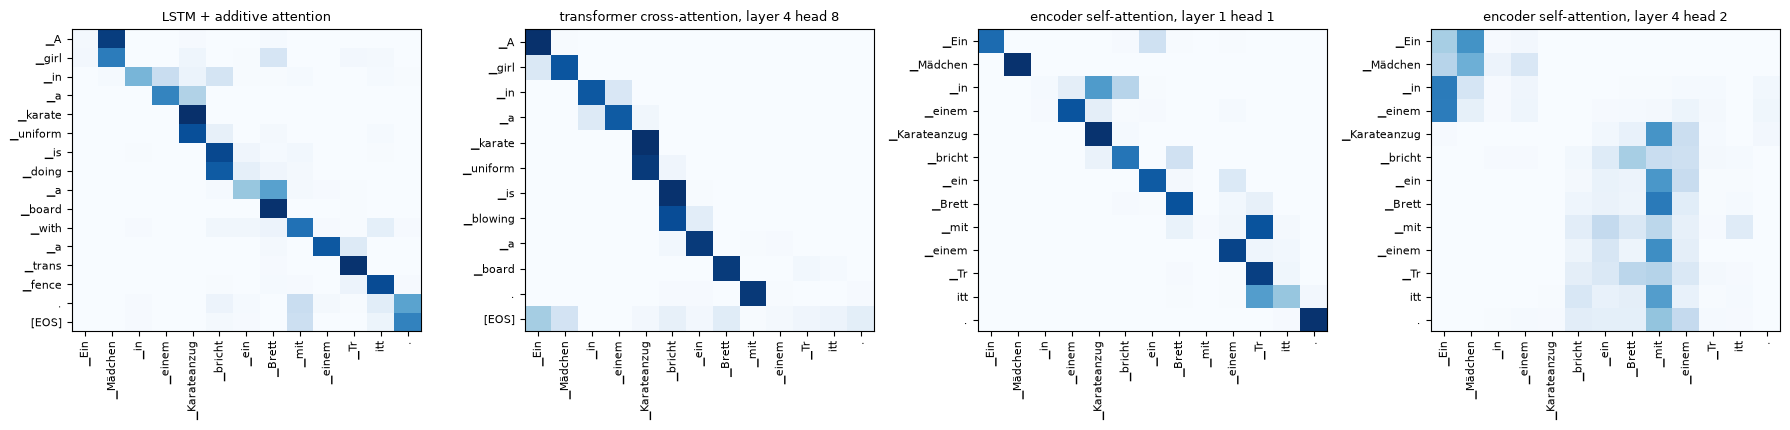

In [45]:
# pick the cross-attention head whose map is closest to a permutation (highest average max weight per row)
best = max(((l, h, maps["dec_cross"][l][h].max(1).mean()) for l in range(n_layers) for h in range(n_heads)), key=lambda x: x[2])
fig, axes = plt.subplots(1, 4, figsize=(18, 4.4))
plot_alignment(*lstm_alignment(attn_models["additive"], VIZ[0]), axes[0], title="LSTM + additive attention")
plot_alignment(maps["dec_cross"][best[0]][best[1]], s_tok, t_tok, axes[1], title=f"transformer cross-attention, layer {best[0] + 1} head {best[1] + 1}")
for ax, (l, h) in zip(axes[2:], [(0, 0), (n_layers // 2, 1)]):
    plot_alignment(maps["enc"][l][h], s_tok, s_tok, ax, title=f"encoder self-attention, layer {l + 1} head {h + 1}")
plt.tight_layout(); plt.show()

The encoder self-attention panels are square: German tokens attending to German tokens. Common shapes in the first layers are *previous token*, *next token* and *self* — stripes just off the diagonal — because the cheapest useful thing a first layer can do is build bigrams. Deeper layers get harder to read, and here is the reason.

## 5.2 How to read a stack: the residual stream

One formula per layer, ignoring the FFN for a moment:

$$x_i^{(\ell+1)} = x_i^{(\ell)} + \sum_j \alpha_{ij}^{(\ell)}\, W_V\, x_j^{(\ell)}$$

Every layer *adds* to one running vector per position — the residual stream (Elhage et al. 2021) — and reads from it. Three consequences to say out loud:

1. **The next layer's query is built from what this layer gathered.** $q_i^{(\ell+1)}$, $k_i^{(\ell+1)}$ and $v_i^{(\ell+1)}$ are three projections of the *same* vector $x_i^{(\ell+1)}$ — the token itself (through the residual) plus whatever position $i$ collected from its neighbours. So a second-layer head can ask a question whose *content* depends on the answer a first-layer head fetched. Two layers compose; that composition is where the interesting behaviour of real models lives (the "induction head" — a previous-token head feeding a copy head — is the textbook case, and it will come up when we look at pretrained models).
2. **Attention moves information between positions; the FFN processes it within a position.** Two different jobs, two different sublayers, and the parameter count (block 4.4) says which one the model spends more on.
3. **After the first layer, key $j$ is no longer "word $j$".** It is "word $j$ in context" — which is exactly why deep-layer maps stop looking like word-to-word alignments, and why reading them as such is a mistake.

Decoding here was greedy: the encoder runs once, the decoder re-reads its growing prefix. Beam search was last week's; its successors are a topic for the generation seminars.

# 6. Same class, other tasks

Nothing in `Transformer` knows it is translating German. It maps a sequence of ids to a sequence of ids; the tokenizers, the data and the metric decide what that means. To make the point with numbers rather than words, we train the *same class* on three other tasks — two synthetic and one real — small enough to fit in the remaining minutes, and we look at what the attention learned in each.

## 6.1 Date normalisation

`"the fifth of March, 2021"` → `2021-03-05`

A real class of problem (text normalisation in speech systems, parsing dates and addresses in forms) with a generator we can write in ten lines. Character-level tokens, eleven surface formats, one target format.

In [46]:
MONTHS = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
ORDINALS = ["first", "second", "third", "fourth", "fifth", "sixth", "seventh", "eighth", "ninth", "tenth", "eleventh", "twelfth",
            "thirteenth", "fourteenth", "fifteenth", "sixteenth", "seventeenth", "eighteenth", "nineteenth", "twentieth",
            "twenty-first", "twenty-second", "twenty-third", "twenty-fourth", "twenty-fifth", "twenty-sixth", "twenty-seventh", "twenty-eighth"]


def suffix(d):
    return "th" if 11 <= d <= 13 else {1: "st", 2: "nd", 3: "rd"}.get(d % 10, "th")


def random_date(rng):
    y, m, d = rng.randint(1950, 2049), rng.randint(1, 12), rng.randint(1, 28)
    M = MONTHS[m - 1]
    forms = [f"{M} {d}, {y}", f"{M} {d}{suffix(d)}, {y}", f"{d} {M} {y}", f"{d} {M[:3]} {y}", f"{M[:3]} {d}, {y}",
             f"{m:02d}/{d:02d}/{y}", f"{d:02d}.{m:02d}.{y}", f"{m}/{d}/{y % 100:02d}", f"the {ORDINALS[d - 1]} of {M}, {y}",
             f"{M.lower()} {d} {y}", f"{d}{suffix(d)} {M} {y}"]
    return rng.choice(forms), f"{y:04d}-{m:02d}-{d:02d}"


class CharVocab:
    # the smallest possible tokenizer: one id per character, plus the four specials
    def __init__(self, texts):
        self.itos = SPECIALS + sorted({c for t in texts for c in t})
        self.stoi = {c: i for i, c in enumerate(self.itos)}
        self.sep = ""                       # phonemes will want a space between tokens

    def encode(self, s, bos_eos=False):
        ids = [self.stoi[c] for c in s]
        return torch.tensor([BOS] + ids + [EOS] if bos_eos else ids, dtype=torch.long)

    def decode(self, ids):
        return self.sep.join(self.itos[i] for i in ids if i not in (PAD, BOS, EOS))


def make_task(pairs, vocab_src, vocab_trg, n_train):
    src = [vocab_src.encode(s) for s, _ in pairs]
    trg = [vocab_trg.encode(t, bos_eos=True) for _, t in pairs]
    return (src[:n_train], trg[:n_train]), (src[n_train:], trg[n_train:], None)


@torch.no_grad()
def exact_match(model, src, trg, max_len=16):
    model.eval(); ok = n = 0
    for s, s_len, t in s2s_batches(src, trg, 256, shuffle=False, device=device):
        out = model.greedy(s, s_len, max_len=max_len)
        ids = out[0] if isinstance(out, tuple) else out
        for hyp, ref in zip(ids.tolist(), t.tolist()):
            hyp = hyp[:hyp.index(EOS)] if EOS in hyp else hyp
            ok += hyp == [x for x in ref if x not in (PAD, BOS, EOS)]; n += 1
    return 100 * ok / n


rng = random.Random(SEED)
date_pairs = [random_date(rng) for _ in range(20_000)]
date_vocab = CharVocab([s for s, _ in date_pairs] + [t for _, t in date_pairs])
date_train, date_val = make_task(date_pairs, date_vocab, date_vocab, 18_000)
for s, t in date_pairs[:5]:
    print(f"{s:32s} -> {t}")
print(f"\n{len(date_vocab.itos)} characters; 18 000 training pairs, 2 000 validation")

Feb 1, 2031                      -> 2031-02-01
April 5th, 1981                  -> 1981-04-05
December 18th, 2036              -> 2036-12-18
July 2, 2025                     -> 2025-07-02
the eighth of April, 1961        -> 1961-04-08

50 characters; 18 000 training pairs, 2 000 validation


What exact-match accuracy does it reach on unseen dates — and would the attention LSTM from block 1 get there faster or slower? (Same 64-wide budget; try it after class.)

In [47]:
DATE_EPOCHS = 8

seed_all()
date_tf = Transformer(len(date_vocab.itos), len(date_vocab.itos), d=64, h=4, ff=128, layers=1, dropout=0.1, max_len=48).to(device)
t = time.time()
date_curves = train_transformer(date_tf, (date_train, date_val), device, DATE_EPOCHS,
                                eval_fn=lambda m: (exact_match(m, *date_val[:2]), "exact match %"),
                                peak_lr=2e-3, warmup=200, batch_size=128, label_smoothing=0.0)
print(f"{time.time() - t:.0f}s;  {n_params(date_tf):,} parameters")

epoch 1: train loss 2.415  val loss 0.848  val exact match % 0.55  lr 1.42e-03  (16s)
epoch 2: train loss 0.603  val loss 0.168  val exact match % 49.35  lr 1.68e-03  (24s)
epoch 3: train loss 0.235  val loss 0.078  val exact match % 68.30  lr 1.37e-03  (32s)
epoch 4: train loss 0.149  val loss 0.055  val exact match % 77.60  lr 1.19e-03  (40s)
epoch 5: train loss 0.117  val loss 0.048  val exact match % 78.85  lr 1.06e-03  (47s)
epoch 6: train loss 0.097  val loss 0.042  val exact match % 82.10  lr 9.72e-04  (55s)
epoch 7: train loss 0.083  val loss 0.026  val exact match % 89.80  lr 9.00e-04  (62s)
epoch 8: train loss 0.072  val loss 0.020  val exact match % 92.00  lr 8.42e-04  (70s)
70s;  90,368 parameters


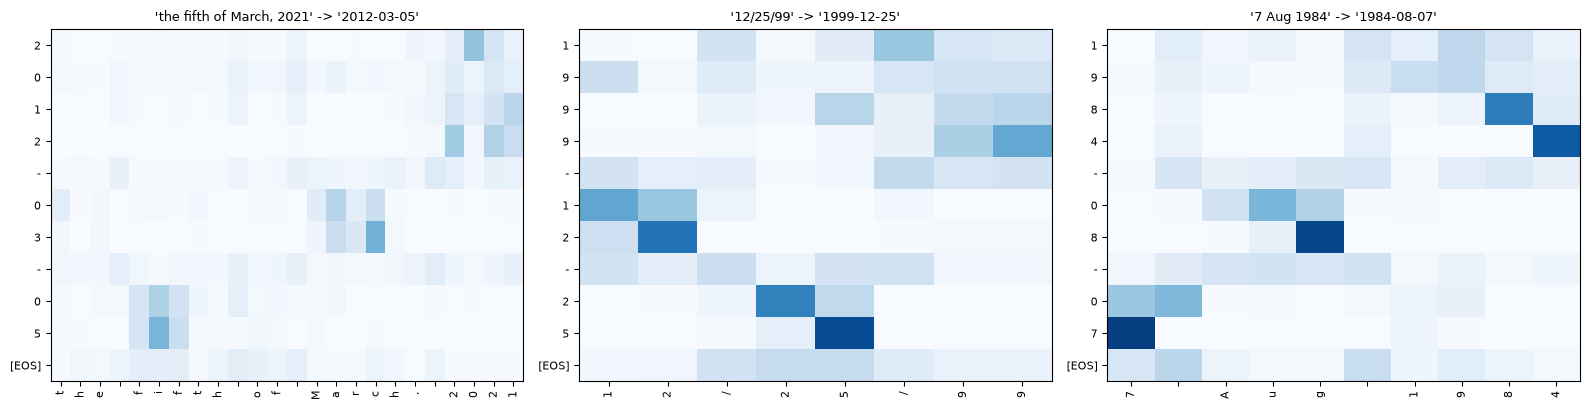

In [48]:
@torch.no_grad()
def task_alignment(model, vocab_src, vocab_trg, s, max_len=16):
    # translate one string and return the head-averaged cross-attention of the last decoder layer
    src = vocab_src.encode(s).unsqueeze(0).to(device); s_len = torch.tensor([src.size(1)])
    ids = model.greedy(src, s_len, max_len=max_len)[0].tolist()
    n = ids.index(EOS) + 1 if EOS in ids else len(ids)
    model(src, s_len, torch.tensor([[BOS] + ids[:n - 1]], device=device))
    w = model.attn["dec_cross"][-1][0].mean(0).cpu().numpy()[:n]
    return w, list(s), [vocab_trg.itos[i] for i in ids[:n]], vocab_trg.decode(ids[:n])


fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, s in zip(axes, ["the fifth of March, 2021", "12/25/99", "7 Aug 1984"]):
    w, st, tt, out = task_alignment(date_tf, date_vocab, date_vocab, s)
    plot_alignment(w, st, tt, ax, title=f"{s!r} -> {out!r}")
plt.tight_layout(); plt.show()

The map is an *algorithm*: the year is copied from the end of the input to the front of the output (the block in the top-right), the month name is read while two digits are written, the day digits are copied straight. 



## 6.2 Reversing a string — and breaking the model

The smallest task with a non-trivial alignment: reverse a sequence of letters. The map should be the anti-diagonal.

Then the experiment that matters: train on lengths 5–12, **test on lengths the model has never seen**, once with sinusoidal positions and once with learned ones.

In [49]:
def reverse_pairs(rng, n, lo, hi):
    letters = "abcdefghijklmnopqrstuvwxyz"
    out = []
    for _ in range(n):
        s = "".join(rng.choice(letters) for _ in range(rng.randint(lo, hi)))
        out.append((s, s[::-1]))
    return out


rng = random.Random(SEED)
rev_vocab = CharVocab(["abcdefghijklmnopqrstuvwxyz"])
rev_train, _ = make_task(reverse_pairs(rng, 12_000, 5, 12), rev_vocab, rev_vocab, 12_000)
rev_test = {L: make_task(reverse_pairs(rng, 300, L, L), rev_vocab, rev_vocab, 0)[1] for L in range(5, 21)}

@torch.no_grad()
def char_accuracy(model, src, trg, max_len=22):
    # per-position accuracy: partial credit, to see whether a model fails gracefully or all at once
    model.eval(); ok = n = 0
    for s, s_len, t in s2s_batches(src, trg, 256, shuffle=False, device=device):
        ids = model.greedy(s, s_len, max_len=max_len)
        for hyp, ref in zip(ids.tolist(), t.tolist()):
            hyp = hyp[:hyp.index(EOS)] if EOS in hyp else hyp
            ref = [x for x in ref if x not in (PAD, BOS, EOS)]
            ok += sum(a == b for a, b in zip(hyp, ref)); n += len(ref)
    return 100 * ok / n


rev_models, rev_exact, rev_char = {}, {}, {}
for pe in ["sin", "learned"]:
    seed_all()
    m = Transformer(len(rev_vocab.itos), len(rev_vocab.itos), d=64, h=4, ff=128, layers=2, dropout=0.0, pe=pe, max_len=24).to(device)
    t = time.time()
    train_transformer(m, (rev_train, rev_test[10]), device, 8, eval_fn=lambda mm: (exact_match(mm, *rev_test[10][:2], max_len=22), "exact@10"),
                      peak_lr=2e-3, warmup=100, batch_size=128, label_smoothing=0.0)
    rev_models[pe] = m
    rev_exact[pe] = {L: exact_match(m, *rev_test[L][:2], max_len=22) for L in rev_test}
    rev_char[pe] = {L: char_accuracy(m, *rev_test[L][:2]) for L in rev_test}
    print(f"pe={pe}: {time.time() - t:.0f}s   exact match by length: { {L: round(a) for L, a in rev_exact[pe].items()} }")

epoch 1: train loss 3.272  val loss 2.142  val exact@10 0.00  lr 1.90e-03  (5s)
epoch 2: train loss 1.021  val loss 0.395  val exact@10 25.67  lr 1.45e-03  (8s)
epoch 3: train loss 0.190  val loss 0.062  val exact@10 87.33  lr 1.19e-03  (10s)
epoch 4: train loss 0.046  val loss 0.019  val exact@10 97.67  lr 1.03e-03  (12s)
epoch 5: train loss 0.024  val loss 0.016  val exact@10 97.33  lr 9.22e-04  (15s)
epoch 6: train loss 0.017  val loss 0.006  val exact@10 99.33  lr 8.41e-04  (18s)
epoch 7: train loss 0.011  val loss 0.028  val exact@10 92.33  lr 7.79e-04  (20s)
epoch 8: train loss 0.011  val loss 0.006  val exact@10 97.67  lr 7.29e-04  (22s)
pe=sin: 50s   exact match by length: {5: 98, 6: 98, 7: 100, 8: 99, 9: 98, 10: 98, 11: 99, 12: 95, 13: 16, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 20: 0}
epoch 1: train loss 3.341  val loss 2.347  val exact@10 0.00  lr 1.90e-03  (3s)
epoch 2: train loss 1.459  val loss 0.928  val exact@10 1.00  lr 1.45e-03  (6s)
epoch 3: train loss 0.531  val l

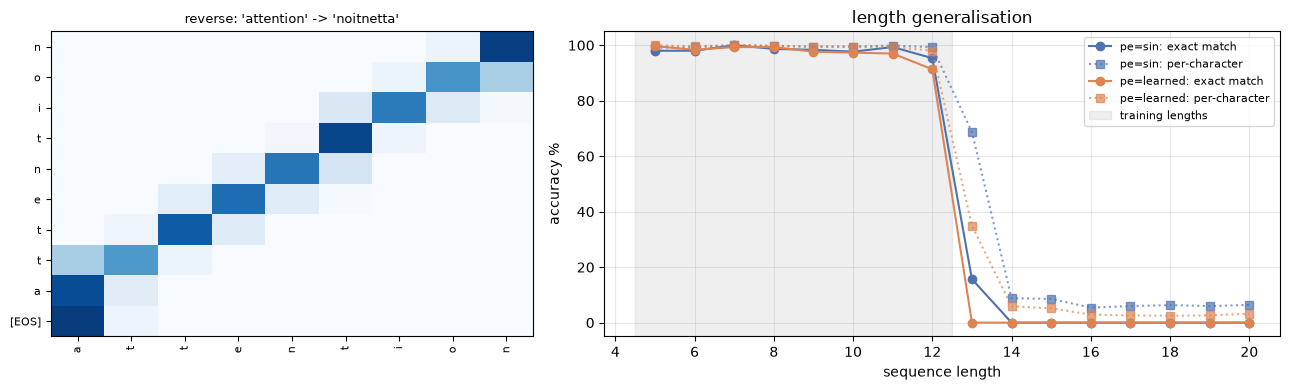

In [50]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1, 1.4]})
w, st, tt, out = task_alignment(rev_models["sin"], rev_vocab, rev_vocab, "attention", max_len=22)
plot_alignment(w, st, tt, a1, title=f"reverse: {'attention'!r} -> {out!r}")
for pe, c in [("sin", "#4c72b0"), ("learned", "#dd8452")]:
    a2.plot(list(rev_exact[pe].keys()), list(rev_exact[pe].values()), "o-", color=c, label=f"pe={pe}: exact match")
    a2.plot(list(rev_char[pe].keys()), list(rev_char[pe].values()), "s:", color=c, alpha=.7, label=f"pe={pe}: per-character")
a2.axvspan(4.5, 12.5, color="gray", alpha=.12, label="training lengths")
a2.set_xlabel("sequence length"); a2.set_ylabel("accuracy %"); a2.legend(fontsize=8); a2.grid(alpha=.3); a2.set_title("length generalisation")
plt.tight_layout(); plt.show()

Inside the training range both are near-perfect. One position past it, both fall off a cliff — the sinusoid keeps a fraction of the characters right at length 13, the learned table almost none, and by 14 both are at zero. The learned table has *no row* it was ever trained on for positions 13–20: they were initialised and never updated, so the model has no idea where those tokens are. The sinusoid has a well-defined vector for every position, which buys it about one extra length and nothing more — the model learned to read "position $S - t$" only for the $S$ it saw. Neither generalises; that is the honest state of the art, and it is why position encoding is still an active research topic (and we'll talk about RoPE later).


# 7. Where this goes

Put the results table back up and read it as one story.

In [51]:
show_results()

,params,test BLEU,BLEU 0-10,BLEU 25+,s/epoch,note
model,,,,,,
"LSTM, no attention (week 2)",8.0M,13.4,18.17,8.51,167,one vector between the halves
LSTM + additive attention,8.7M,36.3,41.72,21.62,59,"6 epochs, Bahdanau 2015"
LSTM + general attention,8.6M,19.1,24.99,10.98,51,Luong 2015
LSTM + scaled_dot attention,8.6M,36.7,44.14,23.01,72,Vaswani 2017 scoring
"Transformer, 1 layer",5.9M,39.2,45.28,23.95,34,15 epochs
"Transformer, 3 layers",9.6M,40.1,46.62,28.59,54,15 epochs
"Transformer, 6 layers",15.2M,40.1,47.53,27.98,80,15 epochs
"Transformer, 6 layers, no cross-attention",15.2M,26.1,38.56,12.95,81,"15 epochs, mean-pooled memory"
"Transformer, 6 layers, no positions",15.2M,31.7,43.07,15.31,73,"15 epochs, pe=none"


<!-- REVISE AFTER PRECOMPUTE: align the story with the numbers. -->

Every row is one formula — a query, keys, a weighted sum of values — used in a different place:

* **nowhere** (row 0): one vector between the halves, and the translation loses the details of anything long;
* **between the decoder and the encoder** (rows 1–3): access replaces the summary, the slope goes away, and the score function — the part with the most papers — barely moves the number;
* **everywhere** (the transformer rows): self-attention replaces recurrence, training becomes parallel, and the two ablations say where the gain comes from — cross-attention (remove it and the bottleneck is back) and positions (remove them and the encoder is a bag of words).


## Try it yourself

The cells below are set up with `RUN_HOMEWORK = False`; flip it and fill in what is missing.

* **Length generalisation, third curve.** Implement rotary position embeddings (Su et al. 2021): rotate each pair of dimensions of $q$ and $k$ by an angle proportional to the position before the dot product, inside `MultiHeadAttention`. Retrain the reverse task with it and add its curve to the plot of 6.2. Which of the three degrades most gracefully past length 12, and why does a *relative* encoding have a chance where an absolute one does not?
* **Without $\sqrt{d_k}$.** Set the attention LSTM to `score="dot"` and train two epochs on 10 000 pairs with `hidden=256` and, separately, with the keys and queries projected to 1 024 dimensions. Record the entropy of the attention weights after the first 50 steps and the BLEU after two epochs. Where does the missing scale hurt, and where does it not?
* **Coverage** (open question 1). For every test sentence, count the German tokens that never receive a weight above 0.3 from any target position, under the additive LSTM. Plot the count against the sentence's BLEU. Is under-attended source a predictor of a bad translation?

In [ ]:
RUN_HOMEWORK = False

if RUN_HOMEWORK:
    # --- label smoothing: perplexity and BLEU disagree ---
    rows = []
    for eps in [0.0, 0.1]:
        seed_all()
        m = Transformer(V_DE, V_EN, d=256, h=8, ff=1024, layers=1).to(device)
        c = train_transformer(m, data, device, 3, eval_fn=lambda mm: (s2s_bleu(mm, tok_en, va_src, va_trg, va_en, device)[0], "BLEU"),
                              label_smoothing=eps)
        rows.append({"label smoothing": eps, "val perplexity": round(math.exp(c["val_loss"][-1]), 2), "val BLEU": c["val_score"][-1]})
    display(pd.DataFrame(rows).set_index("label smoothing"))

    # --- coverage: source tokens nobody looked at, vs sentence BLEU ---
    m = attn_models["additive"]
    under, sent_bleu = [], []
    for i in range(300):
        w, st, tt = lstm_alignment(m, i)
        under.append(int((w.max(0) < 0.3).sum()))
        sent_bleu.append(sacrebleu.sentence_bleu(attn_hyps["additive"][i], [te_en[i]]).score)
    plt.figure(figsize=(6, 3.5)); plt.scatter(under, sent_bleu, alpha=.4); plt.xlabel("source tokens with max attention < 0.3"); plt.ylabel("sentence BLEU"); plt.grid(alpha=.3); plt.show()
    print("correlation:", np.corrcoef(under, sent_bleu)[0, 1].round(3))

## References

* Bahdanau, Cho, Bengio (2015). [*Neural Machine Translation by Jointly Learning to Align and Translate.*](https://arxiv.org/abs/1409.0473) ICLR. — attention.
* Luong, Pham, Manning (2015). [*Effective Approaches to Attention-based Neural Machine Translation.*](https://arxiv.org/abs/1508.04025) EMNLP. — dot / general / concat scores, global vs local, input feeding.
* Xu et al. (2015). [*Show, Attend and Tell.*](https://arxiv.org/abs/1502.03044) ICML. — hard vs soft attention.
* Graves, Wayne, Danihelka (2014). [*Neural Turing Machines.*](https://arxiv.org/abs/1410.5401) — content-based addressing before MT.
* Tu et al. (2016). [*Modeling Coverage for Neural Machine Translation.*](https://arxiv.org/abs/1601.04811) ACL.
* Vaswani et al. (2017). [*Attention Is All You Need.*](https://arxiv.org/abs/1706.03762) NeurIPS. — the transformer.
* Shaw, Uszkoreit, Vaswani (2018). [*Self-Attention with Relative Position Representations.*](https://arxiv.org/abs/1803.02155) NAACL.
* Su et al. (2021). [*RoFormer: Enhanced Transformer with Rotary Position Embedding.*](https://arxiv.org/abs/2104.09864) — RoPE.
* Press, Smith, Lewis (2021). [*Train Short, Test Long: Attention with Linear Biases.*](https://arxiv.org/abs/2108.12409) — ALiBi.
* Haviv et al. (2022). [*Transformer Language Models without Positional Encodings Still Learn Positional Information.*](https://arxiv.org/abs/2203.16634) EMNLP Findings.
* He et al. (2016). [*Deep Residual Learning for Image Recognition.*](https://arxiv.org/abs/1512.03385) CVPR.
* Ba, Kiros, Hinton (2016). [*Layer Normalization.*](https://arxiv.org/abs/1607.06450)
* Xiong et al. (2020). [*On Layer Normalization in the Transformer Architecture.*](https://arxiv.org/abs/2002.04745) ICML. — Pre-LN vs Post-LN.
* Szegedy et al. (2016). [*Rethinking the Inception Architecture for Computer Vision.*](https://arxiv.org/abs/1512.00567) CVPR. — label smoothing.
* Press, Wolf (2017). [*Using the Output Embedding to Improve Language Models.*](https://arxiv.org/abs/1608.05859) EACL. — weight tying.
* Dehghani et al. (2023). [*Scaling Vision Transformers to 22 Billion Parameters.*](https://arxiv.org/abs/2302.05442) — QK-norm.
* Child et al. (2019). [*Generating Long Sequences with Sparse Transformers.*](https://arxiv.org/abs/1904.10509)
* Beltagy, Peters, Cohan (2020). [*Longformer: The Long-Document Transformer.*](https://arxiv.org/abs/2004.05150)
* Katharopoulos et al. (2020). [*Transformers are RNNs: Fast Autoregressive Transformers with Linear Attention.*](https://arxiv.org/abs/2006.16236) ICML.
* Shazeer (2019). [*Fast Transformer Decoding: One Write-Head is All You Need.*](https://arxiv.org/abs/1911.02150) — multi-query attention.
* Ainslie et al. (2023). [*GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints.*](https://arxiv.org/abs/2305.13245) EMNLP.
* Elhage et al. (2021). [*A Mathematical Framework for Transformer Circuits.*](https://transformer-circuits.pub/2021/framework/index.html) — the residual stream, induction heads.
* Elliott et al. (2016). [*Multi30K: Multilingual English-German Image Descriptions.*](https://aclanthology.org/W16-3210/) — the data.
* Post (2018). [*A Call for Clarity in Reporting BLEU Scores.*](https://arxiv.org/abs/1804.08771) WMT. — `sacrebleu`.
* [CMU Pronouncing Dictionary](https://github.com/cmusphinx/cmudict) — the g2p data (BSD licence).
* Next week: Devlin et al. (2019) [*BERT*](https://arxiv.org/abs/1810.04805); Clark et al. (2019) [*What Does BERT Look At?*](https://arxiv.org/abs/1906.04341); Voita et al. (2019) [*Analyzing Multi-Head Self-Attention.*](https://arxiv.org/abs/1905.09418)